# Full Model Development Notebook
**Multi-Aspect Sentiment Analysis - RoBERTa + Dependency GCN**

This notebook covers the **entire ML pipeline** from raw data loading to final evaluation plots:




---
## Section 1 - Setup & Configuration


In [6]:
# Run this cell only if any library is missing
# !pip install torch transformers scikit-learn pandas numpy matplotlib seaborn tqdm spacy
# !python -m spacy download en_core_web_sm

In [2]:
import os, sys, json, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from collections import Counter
from tqdm import tqdm

# Transformers
from transformers import RobertaModel, RobertaTokenizer, get_linear_schedule_with_warmup

# Dataset / DataLoader
from torch.utils.data import Dataset, DataLoader

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, matthews_corrcoef,
    roc_auc_score, roc_curve, auc
)

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}  ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'})")


PyTorch  : 2.5.1+cu121
CUDA     : True  (NVIDIA GeForce RTX 4060 Laptop GPU)


In [3]:
# ─────────────────────────────────────────────────────────────────────
# RUN_PIPELINE flag
#
# Controls whether the 'execution' cells in this notebook actually run.
#   True  → run this notebook normally (load data, train model, evaluate)
#   False → only define classes/functions and then stop
#           (used when 08_experiments.ipynb calls %run on this notebook
#            so it can borrow our class definitions without re-training)
#
# How it works:
#   08_experiments.ipynb writes  builtins._NB_RUN_PIPELINE = False  before
#   calling %run.  getattr() below reads that value, defaulting to True
#   when this notebook is run normally (no external caller set the flag).
# ─────────────────────────────────────────────────────────────────────
import builtins
RUN_PIPELINE = getattr(builtins, '_NB_RUN_PIPELINE', True)
print(f'RUN_PIPELINE = {RUN_PIPELINE}  '
      f'({"normal run" if RUN_PIPELINE else "definition-only mode — execution cells will be skipped"})')


RUN_PIPELINE = True  (normal run)


In [5]:
# ─────────────────────────────────────────────────────────────────────
# Configuration
#
# Loads ALL settings from configs/config.yaml — the single source of truth.
# Relative data paths (train/val/test CSV files) are resolved to absolute
# paths so the notebook works regardless of which directory Jupyter started in.
#
# OUTPUT_DIR  — where model checkpoints and result files are saved
#   outputs/notebook_run/best_model.pt   ← best checkpoint (saved each epoch)
#   outputs/notebook_run/test_results.json  ← all per-aspect test metrics
#   outputs/notebook_run/errors.csv      ← misclassified samples
# ─────────────────────────────────────────────────────────────────────
import yaml, os
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
ML_ROOT      = NOTEBOOK_DIR.parent.parent      # ml-research/
CONFIG_PATH  = ML_ROOT / 'configs' / 'config.yaml'

with open(CONFIG_PATH, 'r') as f:
    CONFIG = yaml.safe_load(f)

# Make data paths absolute so the notebook works from any working directory
for key in ('train_path', 'val_path', 'test_path'):
    CONFIG['data'][key] = str(ML_ROOT / CONFIG['data'][key])

# Enable MSR evaluation in this notebook run
CONFIG.setdefault('experiment', {})['evaluate_msr'] = True

# Output directory for this notebook's runs 
RESULTS_DIR     = ML_ROOT / 'outputs' / 'cosmetic_sentiment_v1'
CHECKPOINT_PATH = RESULTS_DIR / 'best_model.pt'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import torch
DEVICE = torch.device(CONFIG['hardware']['device'] if torch.cuda.is_available() else 'cpu')

print(f'Config loaded from : {CONFIG_PATH}')
print(f'Output directory   : {RESULTS_DIR}')
print(f'  Checkpoint       : {CHECKPOINT_PATH}')
print(f'  Results JSON     : {RESULTS_DIR / "test_results.json"}')
print(f'  Error log CSV    : {RESULTS_DIR / "errors.csv"}')
print(f'Device             : {DEVICE}')
print(f'Aspects            : {CONFIG["aspects"]["names"]}')


Config loaded from : c:\Users\lucif\Desktop\Clearview\ml-research\configs\config.yaml
Output directory   : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\cosmetic_sentiment_v1
  Checkpoint       : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\cosmetic_sentiment_v1\best_model.pt
  Results JSON     : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\cosmetic_sentiment_v1\test_results.json
  Error log CSV    : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\cosmetic_sentiment_v1\errors.csv
Device             : cuda
Aspects            : ['stayingpower', 'texture', 'smell', 'price', 'colour', 'shipping', 'packing']


---
## Section 2 - Data Utilities

Provides all data utilities needed to train and evaluate the multi-aspect sentiment model.

---


In [6]:
class DependencyParser:
    """Thin wrapper around spaCy for building dependency edge_index tensors."""

    def __init__(self, model_name='en_core_web_sm'):
        import spacy
        print(f"[DepParser] Loading spaCy model: {model_name}")
        try:
            self.nlp = spacy.load(model_name)
        except OSError:
            print(f"[DepParser] Not found — downloading {model_name}...")
            import subprocess
            subprocess.run(['python', '-m', 'spacy', 'download', model_name], check=True)
            self.nlp = spacy.load(model_name)
        print("[DepParser] Ready")

    def parse(self, text):
        """
        Returns:
            tokens     : list of token strings
            edge_index : (2, num_edges) LongTensor  [head → dependent]
            edge_types : list of dependency relation strings
        """
        doc        = self.nlp(text)
        tokens     = [t.text for t in doc]
        edges      = []
        edge_types = []
        for token in doc:
            if token.head != token:
                edges.append([token.head.i, token.i])
                edge_types.append(token.dep_)
        edge_index = (
            torch.tensor(edges, dtype=torch.long).t()
            if edges
            else torch.zeros((2, 0), dtype=torch.long)
        )
        return tokens, edge_index, edge_types


In [7]:
class CosmeticReviewDataset(Dataset):
    """
    Reads a CSV split and expands each row into one sample per labelled aspect.
    A single review that covers 3 aspects becomes 3 separate training samples.
    """

    def __init__(self, data_path, tokenizer, config, aspect_names, is_train=True):
        split = 'train' if is_train else 'val/test'
        print(f"\n[Dataset] Loading {split} split from: {data_path}")

        self.data         = pd.read_csv(data_path)
        self.tokenizer    = tokenizer
        self.config       = config
        self.aspect_names = aspect_names
        self.is_train     = is_train
        self.max_length   = config['data']['max_seq_length'] # RoBERTa max is 512; using 128 for speed
        self.text_column  = config['data']['text_column'] # Column name in the CSV that holds review text
        self.label_map    = config['aspects']['label_map'] # {"negative": 0, "neutral": 1, "positive": 2}

        print(f"[Dataset] {len(self.data)} rows  |  text_column='{self.text_column}'  |  max_len={self.max_length}")
        self.samples = self._prepare_samples()

        print(f"[Dataset] Expanded to {len(self.samples)} samples")
        self._print_statistics()

    def _prepare_samples(self):
        samples, skipped = [], 0
        for idx, row in tqdm(self.data.iterrows(), total=len(self.data), desc='  Expanding rows'):
            text = str(row[self.text_column]) if pd.notna(row[self.text_column]) else ''
            if not text.strip():
                skipped += 1
                continue
            for aspect in self.aspect_names:
                # NaN in an aspect column means the review was not labelled for that aspect
                if pd.notna(row[aspect]):
                    label_str = str(row[aspect]).lower()
                    if label_str in self.label_map: # Skip any malformed labels
                        samples.append({
                            'text'        : text,
                            'aspect'      : aspect,
                            'aspect_id'   : self.aspect_names.index(aspect),
                            'label'       : self.label_map[label_str],
                            'original_idx': idx,
                        })
        if skipped:
            print(f"  [Dataset] Skipped {skipped} rows with empty text")
        return samples

    def _print_statistics(self):
        aspect_counts = Counter([s['aspect'] for s in self.samples])
        label_names   = {v: k for k, v in self.label_map.items()}
        label_counts  = Counter([s['label']  for s in self.samples])

        print('[Dataset] Aspect distribution:')
        for asp in self.aspect_names:
            print(f'  {asp:<16}: {aspect_counts.get(asp, 0)}')

        print('[Dataset] Label distribution:')
        for lid in sorted(label_counts):
            print(f'  {label_names[lid]:<10}: {label_counts[lid]}')

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        sample  = self.samples[idx]
        encoding = self.tokenizer(
            sample['text'],
            add_special_tokens=True, # Adds [CLS] at start and [SEP] at end
            max_length=self.max_length,
            padding='max_length',      # Pad shorter sequences so all batches are the same length
            truncation=True,           # Truncate sequences longer than max_length
            return_tensors='pt',       # Return PyTorch tensors
        )
        return {
            'input_ids'    : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0), # (max_length,) — 0 for padding positions
            'aspect_id'    : torch.tensor(sample['aspect_id'], dtype=torch.long),
            'label'        : torch.tensor(sample['label'],     dtype=torch.long),
            'text'         : sample['text'],  # Raw string kept for LIME/SHAP explainability
            'aspect'       : sample['aspect'],
            'review_id'    : sample['original_idx'],
        }


In [8]:
class DependencyParsingDataset(CosmeticReviewDataset):
    """
    Extended dataset that includes dependency parsing information.
    Pre-computes spaCy parse trees once upfront to avoid repeated parsing during training.
    """

    def __init__(self, data_path, tokenizer, config, aspect_names,
                 dependency_parser=None, is_train=True):
        super().__init__(data_path, tokenizer, config, aspect_names, is_train)
        self.dependency_parser = dependency_parser

        if dependency_parser is not None:
            unique_texts = list(set(s['text'] for s in self.samples))
            print(f"[DepDataset] Pre-parsing {len(unique_texts)} unique texts...")
            self.dependency_trees = self._compute_dependency_trees(unique_texts)
        else:
            print('[DepDataset] No parser - edge_index will be empty')
            self.dependency_trees = None

    def _compute_dependency_trees(self, unique_texts):
        trees, errors = {}, []

        for text in tqdm(unique_texts, desc='  Parsing dependency trees'):
            try:
                toks, ei, et = self.dependency_parser.parse(text)
                trees[text]  = {'tokens': toks, 'edge_index': ei, 'edge_types': et}
            except Exception as e:
                errors.append(str(e))
                trees[text] = {'tokens': [], 'edge_index': torch.zeros((2,0), dtype=torch.long), 'edge_types': []}
        if errors:
            print(f"  [DepDataset] {len(errors)} parse errors (empty edge_index used)")
        return trees

    def __getitem__(self, idx):
        item = super().__getitem__(idx)
        
        if self.dependency_trees is not None:
            dep  = self.dependency_trees.get(item['text'], {})
            edge_index   = dep.get('edge_index', torch.zeros((2,0), dtype=torch.long))
            # Prune edges that exceed max_length (spaCy word-level vs RoBERTa BPE)
            if edge_index.size(1) > 0:
                mask = (edge_index[0] < self.max_length) & (edge_index[1] < self.max_length)
                edge_index   = edge_index[:, mask]

            item['edge_index'] = edge_index
            item['tokens']     = dep.get('tokens', [])
            item['edge_types'] = dep.get('edge_types', [])
        return item


In [9]:
print("Starting: Defining function collate_fn_with_dependencies...")

def collate_fn_with_dependencies(batch):
    """Custom collate function for batches with dependency trees."""
    # edge_index tensors have a variable number of edges per sample, so neet to
    # be stacked into fixed-size tensors, keep variable-length edge_index as Python list.
    edge_indices, tokens, edge_types = [], [], []
    for item in batch:
        if 'edge_index' in item:
            edge_indices.append(item['edge_index'])
            tokens.append(item.get('tokens', []))
            edge_types.append(item.get('edge_types', []))
        else:
            # Samples from CosmeticReviewDataset (no dependency parsing) get None
            # so that the model's forward() can detect and skip the GCN branch.
            edge_indices.append(None)
            tokens.append([])
            edge_types.append([])
    return {
        # Fixed-size tensors can be stacked normally
        'input_ids'    : torch.stack([item['input_ids']     for item in batch]),  
        'attention_mask': torch.stack([item['attention_mask'] for item in batch]),
        'aspect_ids'   : torch.stack([item['aspect_id']    for item in batch]),  
        'labels'       : torch.stack([item['label']         for item in batch]), 
        # Variable-length / non-tensor fields stay as Python lists
        'review_ids'   : [item['review_id'] for item in batch],
        'texts'        : [item['text']      for item in batch],
        'aspects'      : [item['aspect']    for item in batch],
        'edge_indices' : edge_indices, 
        'tokens'       : tokens,
        'edge_types'   : edge_types,
    }
print("Completed: Defining function collate_fn_with_dependencies.")


def compute_class_weights(data_path, aspect_names, label_map):
    """Return {aspect: [neg_count, neu_count, pos_count]} from a CSV split."""
    print(f"\n[ClassWeights] Computing from: {data_path}")
    df  = pd.read_csv(data_path)
    aspect_class_counts = {}
    
    for aspect in tqdm(aspect_names, desc='  Counting per aspect'):
        # Counts are ordered by label_id (0=neg, 1=neu, 2=pos)
        counts = [0, 0, 0]
        for label_str, lid in label_map.items():
            counts[lid] = int((df[aspect].astype(str) == label_str).sum())
        aspect_class_counts[aspect] = counts

    for aspect, c in aspect_class_counts.items():
        print(f"  {aspect:<16}: neg={c[0]:>5}  neu={c[1]:>5}  pos={c[2]:>5}")
    return aspect_class_counts


def create_dataloaders(config, tokenizer, dependency_parser=None):
    """Build train / val / test DataLoaders."""
    aspect_names = config['aspects']['names']
    hw           = config['hardware']
    use_dep      = (config['data'].get('use_dependency_parsing', False)
                    and dependency_parser is not None)
    DatasetClass = DependencyParsingDataset if use_dep else CosmeticReviewDataset
    extra        = {'dependency_parser': dependency_parser} if use_dep else {}

    print(f"\n[Loaders] Using: {DatasetClass.__name__}  |  batch={config['training']['batch_size']}")
    loaders = []
    for name, path, shuffle in [
        ('train', config['data']['train_path'], True),
        ('val',   config['data']['val_path'],   False),
        ('test',  config['data']['test_path'],  False),
    ]:
        ds = DatasetClass(path, tokenizer, config, aspect_names, is_train=shuffle, **extra)
        loaders.append(DataLoader(
            ds,
            batch_size=config['training']['batch_size'],
            shuffle=shuffle,
            num_workers=hw['num_workers'],
            pin_memory=hw['pin_memory'],
            collate_fn=collate_fn_with_dependencies,
        ))
        print(f"[Loaders] {name}: {len(ds)} samples → {len(loaders[-1])} batches")
    return tuple(loaders)


Starting: Defining function collate_fn_with_dependencies...
Completed: Defining function collate_fn_with_dependencies.


---
## Section 3 - Loss Functions

Defines the loss functions used to train the multi-aspect sentiment model on the **severely imbalanced** cosmetics review dataset.

---

In [10]:
print("Starting: Defining class FocalLoss...")
class FocalLoss(nn.Module):
    """
    Focal Loss - down-weights easy (high-confidence) examples so the model
    focuses its learning on hard / rare samples.

    Args:
        alpha : Per-class weights (list, np.ndarray, or Tensor), or scalar.
        gamma : Focusing exponent.  Higher → stronger focus on hard examples.
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma     = gamma   # Controls how much to focus on hard examples
        self.alpha     = alpha   # Per-class weight
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Compute per-sample cross-entropy (no averaging yet)
        ce_loss    = F.cross_entropy(inputs, targets, reduction='none')
        pt         = torch.exp(-ce_loss)          # Model's confidence on the correct class
        focal_loss = (1 - pt) ** self.gamma * ce_loss  # Down-weight easy examples

        if self.alpha is not None:
            # Map per-class alpha to per-sample alpha_t using target indices
            if isinstance(self.alpha, (list, np.ndarray)):
                alpha_t = torch.tensor(self.alpha, device=inputs.device, dtype=torch.float)[targets]
            elif isinstance(self.alpha, torch.Tensor):
                alpha_t = self.alpha.to(inputs.device)[targets]
            else:
                alpha_t = self.alpha  # Scalar — same weight applied to every sample
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean': return focal_loss.mean()
        if self.reduction == 'sum':  return focal_loss.sum()
        return focal_loss

print("Completed: Defining class FocalLoss.")



Starting: Defining class FocalLoss...
Completed: Defining class FocalLoss.


In [11]:
print("Starting: Defining class ClassBalancedLoss...")
class ClassBalancedLoss(nn.Module):
    """
    Class-Balanced Loss - reweights classes by their
    *effective* number of samples to better handle extreme imbalance.

    Args:
        samples_per_class : [neg_count, neu_count, pos_count]
        beta              : 0.9999 for severe imbalance, 0.999 for moderate
    """
    def __init__(self, samples_per_class, beta=0.9999, reduction='mean'):
        super().__init__()

        effective_num = 1.0 - np.power(beta, samples_per_class)  # E_n = 1 - β^n
        weights       = (1.0 - beta) / np.array(effective_num)   # Normalise by (1-β)
        weights       = weights / weights.sum() * len(weights)    # Scale so mean = 1
        self.weights  = torch.tensor(weights, dtype=torch.float32)
        self.reduction = reduction

    def forward(self, inputs, targets):
        if self.weights.device != inputs.device:
            self.weights = self.weights.to(inputs.device)
        # Standard CrossEntropy, but weighted by the effective-number weights
        return F.cross_entropy(inputs, targets, weight=self.weights, reduction=self.reduction)
print(" Completed: Defining class ClassBalancedLoss.")

Starting: Defining class ClassBalancedLoss...
 Completed: Defining class ClassBalancedLoss.


In [12]:
print("Starting: Defining class DiceLoss...")
class DiceLoss(nn.Module):
    """
    Generalised Dice Loss - directly maximises F1 (Dice coefficient) for each class.
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth  # Smoothing factor to avoid division by zero

    def forward(self, inputs, targets):
        inputs        = F.softmax(inputs, dim=1)                               # Logits → probabilities
        targets_oh    = F.one_hot(targets, num_classes=inputs.size(1)).float() # Binary indicator matrix
        intersection  = (inputs * targets_oh).sum(dim=0)                       # True-positive-like term, per-class
        cardinality   = inputs.sum(dim=0) + targets_oh.sum(dim=0)              # Predicted + actual totals
        
        # Dice per class = 2*TP / (Predicted + Actual), then average across classes
        dice_score    = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice_score.mean()  # Loss = 1 - Dice (minimise → maximise F1)
print("Completed: Defining class DiceLoss.")

Starting: Defining class DiceLoss...
Completed: Defining class DiceLoss.


In [13]:
print("Starting: Defining class HybridLoss...")
class HybridLoss(nn.Module):
    """
    Weighted sum of Focal + Class-Balanced + Dice losses.
    The `weights` dict controls the contribution of each component.
    """
    def __init__(self, samples_per_class, focal_alpha=None, focal_gamma=2.0,
                 cb_beta=0.9999, weights=None):
        super().__init__()

        if weights is None:
            # Default: Focal is the primary term (weight=1.0), CB corrects for
            # extreme imbalance (weight=0.5), Dice improves minority-class F1 (weight=0.3).
            weights = {'focal': 1.0, 'cb': 0.5, 'dice': 0.3}
            
        self.focal_loss = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)
        self.cb_loss    = ClassBalancedLoss(samples_per_class, beta=cb_beta)
        self.dice_loss  = DiceLoss()
        self.weights    = weights

    def forward(self, inputs, targets):
        loss_focal = self.focal_loss(inputs, targets)   # Focus on hard/rare examples
        loss_cb    = self.cb_loss(inputs, targets)      # Reweight by effective count
        loss_dice  = self.dice_loss(inputs, targets)    # Directly optimise F1

        total_loss = (
            self.weights.get('focal', 0.0) * loss_focal +
            self.weights.get('cb',    0.0) * loss_cb    +
            self.weights.get('dice',  0.0) * loss_dice
        )

        loss_dict = {
            'focal': loss_focal.item(),  
            'cb'   : loss_cb.item(),
            'dice' : loss_dice.item(),
            'total': total_loss.item(),
        }
        return total_loss, loss_dict
print("Completed: Defining class HybridLoss.")

Starting: Defining class HybridLoss...
Completed: Defining class HybridLoss.


In [14]:
print("Starting: Defining class AspectSpecificLossManager...")
class AspectSpecificLossManager:
    """
    Manages aspect-specific loss functions based on class distribution
    Automatically selects appropriate loss parameters for each aspect
    """
    def __init__(self, aspect_class_counts, config):
        self.aspect_losses = {}
        self.config        = config

        for aspect, counts in aspect_class_counts.items():
            # Calculate imbalance ratio
            max_count      = max(counts)
            min_count      = min(counts)
            imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

            # Auto-select gamma: more severe imbalance → higher gamma → stronger focus
            if imbalance_ratio > 50: gamma = 3.0   
            elif imbalance_ratio > 10: gamma = 2.5 
            else: gamma = 2.0                      
            
            # Auto-select beta for Class-Balanced loss
            beta = 0.9999 if imbalance_ratio > 50 else 0.999

            # Inverse-frequency alpha weights
            total       = sum(counts)
            focal_alpha = torch.tensor(
                [total / (len(counts) * c) if c > 0 else 1.0 for c in counts],
                dtype=torch.float32
            )

            self.aspect_losses[aspect] = HybridLoss(
                samples_per_class=counts,
                focal_alpha=focal_alpha,
                focal_gamma=gamma,
                cb_beta=beta,
                weights=config.get('loss_weights', {'focal': 1.0, 'cb': 0.5, 'dice': 0.3})
            )
            print(f"  Loss for [{aspect:<16}]: ratio={imbalance_ratio:>8.1f}  gamma={gamma}  beta={beta}")

    def compute_loss(self, predictions, targets, aspect_ids, aspect_names):
        """
        Compute per-sample loss using each sample's aspect-specific loss function.
        Returns the mean loss over the batch and a dict with per-aspect breakdowns.
        """
        total_loss  = 0
        loss_details = {}

        for i in range(predictions.size(0)):
            aspect_idx = aspect_ids[i].item()
            aspect = aspect_names[aspect_idx] # e.g. 'price'
            
            loss_fn = self.aspect_losses[aspect]# That aspect's HybridLoss
            sample_loss, loss_dict = loss_fn(
                predictions[i].unsqueeze(0),
                targets[i].unsqueeze(0)
            )
            
            total_loss += sample_loss

            # Accumulate loss details
            for key, value in loss_dict.items():
                if aspect not in loss_details:
                    loss_details[aspect] = {}
                if key not in loss_details[aspect]:
                    loss_details[aspect][key] = []
                loss_details[aspect][key].append(value)
        
        total_loss = total_loss / predictions.size(0)  # Average over batch

        # Average loss details
        for aspect in loss_details:
            for key in loss_details[aspect]:
                loss_details[aspect][key] = np.mean(loss_details[aspect][key])

        return total_loss, loss_details

print("Completed: Defining class AspectSpecificLossManager.")


Starting: Defining class AspectSpecificLossManager...
Completed: Defining class AspectSpecificLossManager.


---
## Section 4 - Model Architecture

Defines the **core neural architecture** of the ClearView sentiment model combining :
1. Aspect-aware Multi-Head Attention
2. Dependency GCN
3. Aspect-specific classifiers

---


In [15]:
print("Starting: Defining class AspectAwareRoBERTa...")
class AspectAwareRoBERTa(nn.Module):
    """
    RoBERTa with aspect-specific attention. Improvement over generic [CLS] pooling.
    Each aspect has a learnable embedding used as the query vector, so attention
    focuses on tokens relevant to *that* aspect (e.g. 'smells great' for smell).
    """
    def __init__(self, roberta_model='roberta-base', num_aspects=7,
                 num_classes=3, hidden_dim=768, dropout=0.1,
                 use_aspect_attention=True, use_shared_classifier=False):
        super(AspectAwareRoBERTa, self).__init__()
        
        self.use_aspect_attention  = use_aspect_attention # Ablation 2 flag
        self.use_shared_classifier = use_shared_classifier # Ablation 5 flag

        # Load pre-trained RoBERTa weights
        self.roberta = RobertaModel.from_pretrained(roberta_model)
        
        # Learnable aspect query vectors (one per aspect).
        # Used both for MHA attention queries and for GCN aspect-gating.
        # Xavier uniform init keeps initial gradient magnitudes stable.
        self.aspect_embeddings = nn.Embedding(num_aspects, hidden_dim)
        nn.init.xavier_uniform_(self.aspect_embeddings.weight)
        
        if use_aspect_attention:
            # 8 heads over 768-dim → each head attends over 96-dim subspace.
            # batch_first=True keeps (batch, seq, features) convention throughout.
            self.aspect_attention = nn.MultiheadAttention(
                embed_dim=hidden_dim,
                num_heads=8,
                dropout=dropout,
                batch_first=True
            )

        # Layer normalization
        self.layer_norm = nn.LayerNorm(hidden_dim)
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Ablation 5: shared vs aspect-specific classifiers
        if use_shared_classifier:
            # Single shared classification head for all aspects
            self.shared_classifier = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, num_classes)
            )
        else:
            # Aspect-specific classifiers (separate head for each aspect)
            # Each head specialises for its aspect's class distribution (e.g.
            # price has extreme imbalance; smell/texture are more balanced).
            self.aspect_classifiers = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(hidden_dim, hidden_dim // 2),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                    nn.Linear(hidden_dim // 2, num_classes)
                ) for _ in range(num_aspects)
            ])
        
        self.num_aspects = num_aspects
        self.hidden_dim  = hidden_dim
        
    def forward(self, input_ids, attention_mask, aspect_id, return_token_embeddings=False):
        # Run through pre-trained RoBERTa - Get RoBERTa contextual embeddings
        roberta_output = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        
        hidden_states = roberta_output.last_hidden_state  # (batch_size, seq_len, hidden_dim)
        
        if self.use_aspect_attention:
            # Aspect-guided MHA: the aspect embedding acts as the query, the full token
            # sequence is both key and value. This forces attention to focus on tokens
            # most relevant to THIS aspect (e.g., 'smells great' for the smell aspect).
            aspect_query = self.aspect_embeddings(aspect_id)   # (batch_size, hidden_dim)
            aspect_query = aspect_query.unsqueeze(1)            # (batch_size, 1, hidden_dim) — single query token

            attended_output, attention_weights = self.aspect_attention(
                query=aspect_query,
                key=hidden_states,
                value=hidden_states,
                key_padding_mask=~attention_mask.bool()  # True marks positions to IGNORE (padding)
            )
            aspect_representation = attended_output.squeeze(1)  # (batch_size, hidden_dim) — remove query token dim
        else:
            # Ablation 2: CLS pooling (no aspect awareness)
            # Falls back to the same strategy used by baseline models (PlainRoBERTa, BERT, DistilBERT)
            aspect_representation = hidden_states[:, 0, :]      # (batch_size, hidden_dim)
            # Fake uniform attention weights for interface compatibility
            seq_len = hidden_states.size(1)
            attention_weights = torch.ones(
                hidden_states.size(0), 1, seq_len,
                device=hidden_states.device
            ) / seq_len

        aspect_representation = self.layer_norm(aspect_representation)
        aspect_representation = self.dropout(aspect_representation)
        
        # Route each sample through its aspect-specific classifier using the sample's aspect_id.
        # Loop is necessary because different samples in the batch may have different aspect_ids.
        batch_size = input_ids.size(0)
        predictions = []
        
        for i in range(batch_size):
            if self.use_shared_classifier:
                pred = self.shared_classifier(aspect_representation[i])
            else:
                asp_id = aspect_id[i].item()
                pred   = self.aspect_classifiers[asp_id](aspect_representation[i])
            predictions.append(pred)
        
        predictions = torch.stack(predictions)  # (batch_size, num_classes)
        
        if return_token_embeddings:
            return predictions, attention_weights.squeeze(1), aspect_representation, hidden_states
        
        return predictions, attention_weights.squeeze(1), aspect_representation
print("Completed: Defining class AspectAwareRoBERTa.")

Starting: Defining class AspectAwareRoBERTa...
Completed: Defining class AspectAwareRoBERTa.


In [16]:
print("Starting: Defining class AspectOrientedDepGCN...")
class AspectOrientedDepGCN(nn.Module):
    """
    Dependency GCN with aspect-gated message passing.
    Tokens relevant to the queried aspect receive gate ≈ 1; irrelevant tokens ≈ 0.
    """
    def __init__(self, hidden_dim=768, num_layers=2, dropout=0.1):
        super().__init__()
        self.gcn_layers  = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(num_layers)])   # GCN layers - simple message passing
        self.aspect_gate = nn.Sequential(nn.Linear(hidden_dim * 2, hidden_dim), nn.Sigmoid()) # Aspect gating mechanism
        self.layer_norms = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(num_layers)])
        self.dropout     = nn.Dropout(dropout)
        self.num_layers  = num_layers

    def forward(self, token_embeddings, edge_index, aspect_embedding):
        x         = token_embeddings
        num_nodes = x.size(0)
        for i in range(self.num_layers):
            if edge_index.size(1) > 0:
                src, dst  = edge_index[0], edge_index[1]
                messages  = x[src]
                agg       = torch.zeros_like(x).scatter_add_(0, dst.unsqueeze(1).expand_as(messages), messages)
                x_gcn     = F.relu(self.gcn_layers[i](agg))
            else:
                x_gcn = F.relu(self.gcn_layers[i](x))
            gate  = self.aspect_gate(torch.cat([x_gcn, aspect_embedding.unsqueeze(0).expand(num_nodes, -1)], dim=-1))
            x     = self.layer_norms[i](self.dropout(gate * x_gcn + (1 - gate) * x))
        return x
print("Completed: Defining class AspectOrientedDepGCN.")

Starting: Defining class AspectOrientedDepGCN...
Completed: Defining class AspectOrientedDepGCN.


In [17]:
print("Starting: Defining class MultiAspectSentimentModel...")
class MultiAspectSentimentModel(nn.Module):
    """
    Full model: RoBERTa + Aspect-Aware Attention + Dependency GCN.
    """
    def __init__(self, config):
        super().__init__()
        self.config  = config
        model_config = config['model']
        self.use_gcn = model_config.get('use_dependency_gcn', True)

        self.aspect_aware_roberta = AspectAwareRoBERTa(
            roberta_model        = model_config['roberta_model'],
            num_aspects          = model_config['num_aspects'],
            num_classes          = model_config['num_classes'],
            hidden_dim           = model_config['hidden_dim'],
            dropout              = model_config['dropout'],
            use_aspect_attention = model_config.get('use_aspect_attention', True), # Ablation flags
            use_shared_classifier= model_config.get('use_shared_classifier', False), # Ablation flags
        )
        if self.use_gcn:
            self.dep_gcn = AspectOrientedDepGCN(
                hidden_dim = model_config['hidden_dim'],
                num_layers = model_config['gcn_layers'],
                dropout    = model_config['dropout'],
            )
            # Final classifier with both attention and GCN features
            self.final_classifier = nn.Sequential(
                nn.Linear(model_config['hidden_dim'] * 2, model_config['hidden_dim']),
                nn.ReLU(), nn.Dropout(model_config['dropout']),
                nn.Linear(model_config['hidden_dim'], model_config['num_classes'])
            )

    def forward(self, input_ids, attention_mask, aspect_id,
                edge_index=None, token_mask=None, return_attention=False):
        need_token_embeddings = self.use_gcn and edge_index is not None
        
        # Single forward pass with appropriate parameters based on GCN requirement
        if need_token_embeddings:
            attn_predictions, attention_weights, aspect_repr, token_embeddings = self.aspect_aware_roberta(
                input_ids, attention_mask, aspect_id, return_token_embeddings=True)
        else:
            attn_predictions, attention_weights, aspect_repr = self.aspect_aware_roberta(
                input_ids, attention_mask, aspect_id)
        
        # If dependency parsing is not used, return attention-based predictions
        if not need_token_embeddings:
            if return_attention: return attn_predictions, attention_weights, aspect_repr, None
            return attn_predictions
        
        # Apply Dependency GCN using the token embeddings to each sample in batchfrom above
        gcn_outputs = []
        for i in range(input_ids.size(0)):
            if edge_index is not None and i < len(edge_index) and edge_index[i] is not None and edge_index[i].size(1) > 0:
                # Get aspect embedding for this sample
                aspect_emb = self.aspect_aware_roberta.aspect_embeddings(aspect_id[i])      
                # Apply GCN
                gcn_out = self.dep_gcn(token_embeddings[i], edge_index[i], aspect_emb)             
                # Pool GCN output 
                mask_expanded = attention_mask[i].unsqueeze(-1).float()
                sum_mask = mask_expanded.sum(0)
                gcn_pooled = (gcn_out * mask_expanded).sum(0) / (sum_mask + 1e-9)
                gcn_outputs.append(gcn_pooled)
            else:
                # No dependency tree: fill with zeros so the final_classifier still receives a valid (hidden_dim,) tensor from the GCN branch.
                gcn_outputs.append(torch.zeros_like(aspect_repr[i]))
        
        gcn_output = torch.stack(gcn_outputs)  
        
        # Concatenate attention-based and GCN-based representations.
        # The final_classifier then learns to weight each branch's contribution.
        combined = torch.cat([aspect_repr, gcn_output], dim=-1)  
        
        # Final prediction with combined features
        final_predictions = self.final_classifier(combined)
        
        if return_attention:
            return final_predictions, attention_weights, aspect_repr, gcn_output
        
        return final_predictions
    
    def get_num_parameters(self):
        """Return number of trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("Completed: Defining class MultiAspectSentimentModel.")

def create_model(config):
    """
    Factory function to create model from config
    
    Args:
        config: Configuration dictionary       
    Returns:
        model: MultiAspectSentimentModel
    """
    model = MultiAspectSentimentModel(config)
    print(f"[Model] Created with {model.get_num_parameters():,} trainable parameters")
    return model


Starting: Defining class MultiAspectSentimentModel...
Completed: Defining class MultiAspectSentimentModel.


---
## Section 5 - Training Loop

Training pipeline for the full model for ClearView

---


In [17]:
print("Starting: Defining class Trainer...")
class Trainer:
    """
    Self-contained trainer:
    - AMP (automatic mixed precision) when CUDA is available
    - Gradient clipping
    - Early stopping on validation Macro-F1
    - Checkpoint saved to CHECKPOINT_PATH
    """

    def __init__(self, config, model, loss_manager, tokenizer,
                 train_loader, val_loader, test_loader, device):
        self.config       = config
        self.model        = model.to(device)
        self.loss_manager = loss_manager
        self.device       = device
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.test_loader  = test_loader

        tc             = config['training']
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=tc['learning_rate'], weight_decay=tc['weight_decay']
        )
        total_steps    = len(train_loader) * tc['num_epochs']
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer, num_warmup_steps=tc['warmup_steps'],
            num_training_steps=total_steps
        )
        self.use_amp = config['hardware'].get('mixed_precision', False) and torch.cuda.is_available()
        if self.use_amp:
            from torch.cuda.amp import GradScaler
            self.scaler = GradScaler()

        self.best_val_f1       = 0.0
        self.best_epoch        = 0    # epoch number where best checkpoint was saved
        self.patience_counter  = 0
        self.patience          = tc['early_stopping_patience']
        self.history           = []   # [{epoch, train_loss, val_f1}, ...]
        self.training_duration = 0.0  # filled in by train()

    # ── Forward pass helper ─────────────────────────────────────────────────
    def _forward(self, batch):
        input_ids      = batch['input_ids'].to(self.device)
        attention_mask = batch['attention_mask'].to(self.device)
        aspect_ids     = batch['aspect_ids'].to(self.device)
        edge_indices   = None

        # load spaCy parser for GCN variants
        if self.config['model'].get('use_dependency_gcn', False):
            edge_indices = [e.to(self.device) if e is not None else None
                            for e in batch['edge_indices']]
        return self.model(input_ids, attention_mask, aspect_ids, edge_indices)

    # ── Training epoch ──────────────────────────────────────────────────────
    def train_epoch(self):
        """
        Run one full pass over the training dataloader.

        Returns:
            Average training loss across all batches.
        """
        self.model.train()
        total_loss = 0.0
        aspect_names = self.config['aspects']['names']

        for batch in tqdm(self.train_loader, desc='  Training', leave=False):
            aspect_ids = batch['aspect_ids'].to(self.device)
            labels     = batch['labels'].to(self.device)
            self.optimizer.zero_grad()

            if self.use_amp:
                # AMP (Automatic Mixed Precision): runs forward pass in float16 for speed,
                # then uses GradScaler to safely convert gradients back to float32.
                from torch.cuda.amp import autocast
                with autocast():
                    preds = self._forward(batch)
                    if isinstance(preds, tuple): preds = preds[0]
                    loss, _ = self.loss_manager.compute_loss(preds, labels, aspect_ids, aspect_names)
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config['training']['max_grad_norm'])
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                preds = self._forward(batch)
                if isinstance(preds, tuple): preds = preds[0]
                loss, _ = self.loss_manager.compute_loss(preds, labels, aspect_ids, aspect_names)
                loss.backward()
                # Gradient clipping prevents exploding gradients when fine-tuning RoBERTa
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config['training']['max_grad_norm'])
                self.optimizer.step()
            self.scheduler.step()
            total_loss += loss.item()

        return total_loss / max(len(self.train_loader), 1)

    # ── Evaluation ──────────────────────────────────────────────────────────
    def evaluate(self, loader):
        """
        Evaluate the model on a dataloader and return per-aspect metrics.

        Args:
            loader: DataLoader for the split to evaluate (val or test).

        Returns:
            dict with keys:
              'overall'  → {accuracy, macro_f1, weighted_f1, mcc, ...}
              'aspects'  → {aspect_name: {accuracy, macro_f1, ...}, ...}
        """
        self.model.eval()
        all_preds, all_labels, all_aspects, all_probs, all_texts = [], [], [], [], []
        with torch.no_grad():
            for batch in tqdm(loader, desc='  Evaluating', leave=False):
                preds = self._forward(batch)
                if isinstance(preds, tuple): preds = preds[0]
                probs = torch.softmax(preds, dim=1).cpu().numpy()
                all_probs.extend(probs)
                all_preds.extend(np.argmax(probs, axis=1))
                all_labels.extend(batch['labels'].numpy())
                all_aspects.extend(batch['aspects'])
                all_texts.extend(batch['texts'])

        return {
            'preds'  : np.array(all_preds),
            'labels' : np.array(all_labels),
            'probs'  : np.array(all_probs),
            'aspects': all_aspects,
            'texts'  : all_texts, 
        }

    # ── Full training loop ──────────────────────────────────────────────────
    def train(self, checkpoint_path):
        checkpoint_path = Path(checkpoint_path)
        if checkpoint_path.exists():
            print(f"[Trainer] Checkpoint found at {checkpoint_path} — skipping training.")
            ckpt = torch.load(checkpoint_path, map_location=self.device)
            self.model.load_state_dict(ckpt['model_state_dict'])
            return

        print(f"[Trainer] Starting training for {self.config['training']['num_epochs']} epochs")
        t0 = time.time()
        for epoch in range(self.config['training']['num_epochs']):
            train_loss  = self.train_epoch()
            val_raw     = self.evaluate(self.val_loader)
            val_f1      = f1_score_macro(val_raw['labels'], val_raw['preds'])

            print(f"  Epoch {epoch+1:02d}/{self.config['training']['num_epochs']}  "
                  f"loss={train_loss:.4f}  val_macro_f1={val_f1:.4f}  "
                  f"patience={self.patience_counter}/{self.patience}")

            self.history.append({'epoch': epoch+1, 'train_loss': train_loss, 'val_f1': val_f1})

            if val_f1 > self.best_val_f1:
                self.best_val_f1  = val_f1
                self.patience_counter = 0
                self.best_epoch = epoch + 1
                torch.save({'model_state_dict': self.model.state_dict(), 'config': self.config,
                            'best_epoch': self.best_epoch, 'best_val_f1': val_f1},
                           checkpoint_path)
                print(f"    ✓ New best saved at epoch {self.best_epoch} (val_f1={val_f1:.4f})")
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    break

        self.training_duration = (time.time() - t0) / 60
        print(f"[Trainer] Training complete in {self.training_duration:.1f} min")
        # Load best model
        ckpt = torch.load(checkpoint_path, map_location=self.device)
        self.model.load_state_dict(ckpt['model_state_dict'])


def f1_score_macro(y_true, y_pred):
    _, _, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0, labels=[0, 1, 2]
    )
    return f1


Starting: Defining class Trainer...


---
## Section 6 - Evaluation & Metrics

---


In [16]:
class AspectSentimentEvaluator:
    """
    Computes Accuracy, Macro-F1, Weighted-F1, MCC, per-class F1, and ROC-AUC
    for each aspect.  Results are stored in self.results.

    Primary metric: Macro-F1 — weights all classes equally, critical for imbalanced data.
    """
    def __init__(self, aspect_names):
        self.aspect_names = aspect_names
        self.results      = {}
        print(f"[Evaluator] Tracking {len(aspect_names)} aspects: {aspect_names}")

    def evaluate_aspect(self, y_true, y_pred, aspect_name, y_prob=None):
        n        = len(y_true)
        accuracy = accuracy_score(y_true, y_pred)

        _, _, f1_per_class, _ = precision_recall_fscore_support(
            y_true, y_pred, average=None, zero_division=0, labels=[0, 1, 2]
        )
        prec_per, rec_per, _, support = precision_recall_fscore_support(
            y_true, y_pred, average=None, zero_division=0, labels=[0, 1, 2]
        )
        macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='macro', zero_division=0, labels=[0, 1, 2]
        )
        w_prec, w_rec, weighted_f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='weighted', zero_division=0, labels=[0, 1, 2]
        )
        mcc = matthews_corrcoef(y_true, y_pred)
        cm  = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

        roc_auc = None
        if y_prob is not None:
            try:
                roc_auc = roc_auc_score(y_true, y_prob, labels=[0,1,2],
                                         multi_class='ovr', average='macro')
            except Exception as e:
                print(f"[Evaluator] WARNING: ROC-AUC skipped for {aspect_name}: {e}")

        self.results[aspect_name] = {
            'accuracy'           : accuracy,
            'macro_precision'    : macro_prec,
            'macro_recall'       : macro_rec,
            'macro_f1'           : macro_f1,
            'weighted_precision' : w_prec,
            'weighted_recall'    : w_rec,
            'weighted_f1'        : weighted_f1,
            'mcc'                : mcc,
            'per_class_precision': prec_per,
            'per_class_recall'   : rec_per,
            'per_class_f1'       : f1_per_class,
            'support'            : support,
            'confusion_matrix'   : cm,
            'roc_auc'            : roc_auc,
            'y_true'             : y_true,
            'y_prob'             : y_prob,
        }
        print(f"  [{aspect_name}]  acc={accuracy:.4f}  macro_f1={macro_f1:.4f}  "
              f"mcc={mcc:.4f}  roc_auc={'N/A' if roc_auc is None else f'{roc_auc:.4f}'}")
        print(f"    per-class F1 → neg={f1_per_class[0]:.4f}  "
              f"neu={f1_per_class[1]:.4f}  pos={f1_per_class[2]:.4f}")
        return self.results[aspect_name]

    def evaluate_all(self, raw):
        """Run evaluate_aspect for every aspect and overall, given raw eval dict."""
        all_labels, all_preds, all_probs = raw['labels'], raw['preds'], raw['probs']
        all_aspects = np.array(raw['aspects'])
        for asp in self.aspect_names:
            mask = all_aspects == asp
            if mask.sum() == 0: continue
            self.evaluate_aspect(all_labels[mask], all_preds[mask], asp,
                                  y_prob=all_probs[mask])
        self.evaluate_aspect(all_labels, all_preds, 'overall', y_prob=all_probs)

    def save_results(self, save_path):
        serializable = {}
        for asp, m in self.results.items():
            serializable[asp] = {
                k: v.tolist() if isinstance(v, np.ndarray)
                   else float(v) if isinstance(v, (np.float32, np.float64))
                   else v
                for k, v in m.items()
            }
        with open(save_path, 'w') as f:
            json.dump(serializable, f, indent=2)
        print(f"[Evaluator] Results saved to {save_path}")


class ErrorAnalyzer:
    """
    Post-hoc analysis of misclassified samples — shows which aspect/error type
    the model struggles with most.
    """
    def __init__(self, aspect_names, class_names=('negative', 'neutral', 'positive')):
        self.aspect_names = aspect_names
        self.class_names  = list(class_names)

    def analyze_errors(self, texts, y_true, y_pred, aspects, save_path=None):
        print(f"\n[ErrorAnalyzer] Analysing {len(texts)} predictions...")
        errors = [
            {'text'      : texts[i],
             'aspect'    : aspects[i],
             'true_label': self.class_names[y_true[i]],
             'pred_label': self.class_names[y_pred[i]],
             'error_type': f"{self.class_names[y_true[i]]}→{self.class_names[y_pred[i]]}"}
            for i in range(len(texts)) if y_true[i] != y_pred[i]
        ]
        print(f"Total errors: {len(errors)} / {len(texts)} "
              f"({len(errors)/len(texts)*100:.2f}%)")

        aspect_err = Counter([e['aspect']     for e in errors])
        type_err   = Counter([e['error_type'] for e in errors])

        print("\nError rate by aspect:")
        for asp in sorted(aspect_err):
            total = sum(1 for a in aspects if a == asp)
            print(f"  {asp:<16}: {aspect_err[asp]:>4} / {total} "
                  f"({aspect_err[asp]/total*100:.1f}%)")

        print("\nError type distribution:")
        for etype, cnt in sorted(type_err.items(), key=lambda x: -x[1]):
            print(f"  {etype:<25}: {cnt:>4}  ({cnt/len(errors)*100:.1f}%)")

        if save_path:
            pd.DataFrame(errors).to_csv(save_path, index=False)
            print(f"Errors saved to {save_path}")
        return errors


class MixedSentimentEvaluator:
    """
    Evaluates model performance specifically on reviews with *conflicting*
    sentiments across aspects (e.g. positive colour but negative smell).
    """
    def __init__(self, aspect_names):
        self.aspect_names = aspect_names
        print(f"[MSREvaluator] Tracking {len(aspect_names)} aspects")

    def identify_mixed_sentiment_reviews(self, reviews_data):
        mixed_ids, stats = [], {
            'total_reviews': len(reviews_data), 'mixed_sentiment_reviews': 0,
            'single_aspect_reviews': 0, 'multi_aspect_reviews': 0,
            'conflict_types': {'positive_negative': 0, 'positive_neutral_negative': 0, 'neutral_with_extremes': 0},
        }
        for review in tqdm(reviews_data, desc='  Scanning'):
            active = {a: s for a, s in review['aspects'].items() if s is not None}
            if not active: continue
            if len(active) == 1: stats['single_aspect_reviews'] += 1; continue
            stats['multi_aspect_reviews'] += 1
            sents       = set(active.values())
            has_pos, has_neu, has_neg = 2 in sents, 1 in sents, 0 in sents
            is_mixed    = False
            if has_pos and has_neg:
                is_mixed = True
                if has_neu: stats['conflict_types']['positive_neutral_negative'] += 1
                else:       stats['conflict_types']['positive_negative'] += 1
            elif has_neu and (has_pos or has_neg):
                is_mixed = True
                stats['conflict_types']['neutral_with_extremes'] += 1
            if is_mixed:
                mixed_ids.append(review['review_id'])
                stats['mixed_sentiment_reviews'] += 1
        multi = stats['multi_aspect_reviews']
        stats['mixed_pct_of_multi'] = stats['mixed_sentiment_reviews'] / multi * 100 if multi > 0 else 0.0
        return mixed_ids, stats

    def evaluate_mixed_sentiment_resolution(self, y_true_dict, y_pred_dict):
        data = [{'review_id': rid, 'aspects': y_true_dict[rid]} for rid in y_true_dict]
        mixed_ids, stats = self.identify_mixed_sentiment_reviews(data)
        if not mixed_ids:
            print('[MSREvaluator] No mixed reviews found')
            return {'mixed_review_count': 0, 'stats': stats}
        correct_reviews = correct_aspects = total_aspects = 0
        for rid in tqdm(mixed_ids, desc='  Scoring'):
            if rid not in y_pred_dict: continue
            true_asp, pred_asp = y_true_dict[rid], y_pred_dict[rid]
            all_correct = True
            for asp in true_asp:
                if asp in pred_asp:
                    total_aspects += 1
                    if true_asp[asp] == pred_asp[asp]: correct_aspects += 1
                    else: all_correct = False
                else: all_correct = False
            if all_correct: correct_reviews += 1

        review_acc = correct_reviews / len(mixed_ids) * 100
        aspect_acc = correct_aspects / total_aspects  * 100 if total_aspects > 0 else 0.0
        print(f"[MSR] Review-level accuracy: {review_acc:.2f}%  |  "
              f"Aspect-level accuracy: {aspect_acc:.2f}%")
        return {
            'mixed_review_count'   : len(mixed_ids),
            'mixed_prevalence'     : stats['mixed_pct_of_multi'],
            'mixed_review_accuracy': review_acc,
            'mixed_aspect_accuracy': aspect_acc,
            'stats'                : stats,
            'total_mixed_aspects'  : total_aspects,
            'correct_mixed_aspects': correct_aspects,
        }


---
## Section 7 - Visualizations
---

In [15]:
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']


def plot_confusion_matrix(results, aspect_name):
    """Heatmap confusion matrix for a single aspect."""
    if aspect_name not in results:
        print(f'Aspect "{aspect_name}" not found in results'); return
    cm = results[aspect_name]['confusion_matrix']
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix — {aspect_name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout(); plt.show()


def plot_all_confusion_matrices(results, aspects=None):
    """Grid of confusion matrices for all tracked aspects."""
    aspects = aspects or [k for k in results if k != 'overall']
    ncols   = 3
    nrows   = (len(aspects) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()
    for i, asp in enumerate(aspects):
        if asp not in results: axes[i].axis('off'); continue
        cm = results[asp]['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[i])
        axes[i].set_title(asp); axes[i].set_xlabel('Pred'); axes[i].set_ylabel('True')
    for j in range(i+1, len(axes)): axes[j].axis('off')
    plt.suptitle('Confusion Matrices — All Aspects', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()


def plot_roc_curve(results, aspect_name):
    """Multiclass (One-vs-Rest) ROC curve for a single aspect."""
    if aspect_name not in results:
        print(f'Aspect "{aspect_name}" not found in results'); return
    r     = results[aspect_name]
    if r['y_prob'] is None:
        print(f'No probability estimates for {aspect_name}'); return
    y_true = r['y_true']
    y_prob = r['y_prob']

    fig, ax = plt.subplots(figsize=(6, 5))
    colours = ['#e74c3c', '#3498db', '#2ecc71']
    for cls_idx, (cls_name, col) in enumerate(zip(CLASS_NAMES, colours)):
        y_bin         = (y_true == cls_idx).astype(int)
        fpr, tpr, _   = roc_curve(y_bin, y_prob[:, cls_idx])
        auc_val       = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{cls_name} (AUC={auc_val:.3f})', color=col, lw=2)
    ax.plot([0,1],[0,1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {aspect_name}\n(Macro ROC-AUC = {r["roc_auc"]:.4f})')
    ax.legend(loc='lower right')
    plt.tight_layout(); plt.show()


def plot_all_roc_curves(results, aspects=None):
    """Grid of ROC curves for all tracked aspects."""
    aspects = aspects or [k for k in results if k != 'overall' and results[k].get('y_prob') is not None]
    ncols   = 3
    nrows   = (len(aspects) + ncols - 1) // ncols
    colours = ['#e74c3c', '#3498db', '#2ecc71']
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    axes = axes.flatten()
    for i, asp in enumerate(aspects):
        r = results[asp]
        if r.get('y_prob') is None: axes[i].axis('off'); continue
        y_true, y_prob = r['y_true'], r['y_prob']
        for cls_idx, (cls_name, col) in enumerate(zip(CLASS_NAMES, colours)):
            y_bin       = (y_true == cls_idx).astype(int)
            fpr, tpr, _ = roc_curve(y_bin, y_prob[:, cls_idx])
            auc_val     = auc(fpr, tpr)
            axes[i].plot(fpr, tpr, label=f'{cls_name} ({auc_val:.2f})', color=col, lw=1.5)
        axes[i].plot([0,1],[0,1],'k--',lw=1)
        axes[i].set_title(f'{asp}\nMacro AUC={r["roc_auc"]:.3f}')
        axes[i].legend(fontsize=7); axes[i].set_xlabel('FPR'); axes[i].set_ylabel('TPR')
    for j in range(i+1, len(axes)): axes[j].axis('off')
    plt.suptitle('ROC Curves — All Aspects', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()


def compare_aspects(results):
    """Bar chart comparing Accuracy, Macro-F1, Weighted-F1, MCC across all aspects."""
    aspects = [k for k in results if k != 'overall']
    metrics = ['accuracy', 'macro_f1', 'weighted_f1', 'mcc']
    labels  = ['Accuracy', 'Macro-F1', 'Weighted-F1', 'MCC']
    colours = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

    x     = np.arange(len(aspects))
    width = 0.2
    fig, ax = plt.subplots(figsize=(max(10, len(aspects)*1.5), 5))
    for i, (metric, label, col) in enumerate(zip(metrics, labels, colours)):
        vals = [results[asp].get(metric, 0) for asp in aspects]
        ax.bar(x + i*width, vals, width, label=label, color=col, alpha=0.85)
    ax.set_xticks(x + width*1.5); ax.set_xticklabels(aspects, rotation=30, ha='right')
    ax.set_ylim(0, 1.05)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title('Per-Aspect Performance Comparison', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score'); ax.legend()
    plt.tight_layout(); plt.show()


def plot_training_history(history):
    """Plot training loss and validation Macro-F1 over epochs."""
    epochs     = [h['epoch']      for h in history]
    losses     = [h['train_loss'] for h in history]
    val_f1s    = [h['val_f1']     for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, losses, 'b-o', ms=4); ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax2.plot(epochs, val_f1s, 'g-o', ms=4); ax2.set_title('Validation Macro-F1')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro-F1')
    plt.suptitle('Training Progress', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


---
## Section 8 - Run: Build Everything & Train

Run all cells above first, then run this section to actually train the model.

---


In [17]:
if RUN_PIPELINE:
    # ── Tokenizer ─────────────────────────────────────────────────────────
    # Converts raw review text into integer token IDs that RoBERTa understands.
    # The tokenizer vocabulary and special tokens ([CLS], [SEP], <pad>) are
    # downloaded from HuggingFace and cached locally on first run.
    from transformers import RobertaTokenizer
    tokenizer = RobertaTokenizer.from_pretrained(CONFIG['model']['roberta_model'])
    print(f'Tokenizer loaded: {CONFIG["model"]["roberta_model"]}')
    print(f'Vocabulary size: {tokenizer.vocab_size:,}')

    # ── Dependency parser ─────────────────────────────────────
    # Builds a syntactic dependency graph (edges between words) for each review.
    # Used by the AspectOrientedDepGCN to capture grammatical relationships.
    # If use_dependency_gcn is False in config, this is skipped entirely.
    dep_parser = None
    if CONFIG['data'].get('use_dependency_parsing', False):
        print('Initialising spaCy dependency parser...')
        dep_parser = DependencyParser('en_core_web_sm')

    # ── DataLoaders ───────────────────────────────────────────────────────
    # Creates three PyTorch DataLoaders (train / val / test).
    # Each batch contains: input_ids, attention_mask, aspect_ids, labels,
    # aspects (string names), review_ids, and (optionally) edge_indices for GCN.
    print('Building dataloaders...')
    train_loader, val_loader, test_loader = create_dataloaders(
        CONFIG, tokenizer, dep_parser
    )
    print(f'Train batches : {len(train_loader)}')
    print(f'Val   batches : {len(val_loader)}')
    print(f'Test  batches : {len(test_loader)}')

    # ── Class weights ─────────────────────────────────────────────────────
    # Counts how many negative/neutral/positive samples exist per aspect in
    # the training set. These counts are passed to AspectSpecificLossManager
    # so it can calculate class-balanced loss weights automatically.
    print('Computing class distribution in training set...')
    aspect_class_counts = compute_class_weights(
        CONFIG['data']['train_path'],
        CONFIG['aspects']['names'],
        CONFIG['aspects']['label_map'],
    )
    for asp, counts in aspect_class_counts.items():
        print(f'  {asp:<12}: neg={counts[0]:>4}  neu={counts[1]:>4}  pos={counts[2]:>4}')


Tokenizer loaded: roberta-base
Vocabulary size: 50,265
Initialising spaCy dependency parser...
[DepParser] Loading spaCy model: en_core_web_sm
[DepParser] Ready
Building dataloaders...

[Loaders] Using: DependencyParsingDataset  |  batch=16

[Dataset] Loading train split from: c:\Users\lucif\Desktop\Clearview\ml-research\data\splits\train_augmented.csv
[Dataset] 10050 rows  |  text_column='data'  |  max_len=256


  Expanding rows: 100%|██████████| 10050/10050 [00:00<00:00, 22647.51it/s]


[Dataset] Expanded to 22440 samples
[Dataset] Aspect distribution:
  stayingpower    : 2047
  texture         : 3622
  smell           : 2277
  price           : 2714
  colour          : 5410
  shipping        : 3889
  packing         : 2481
[Dataset] Label distribution:
  negative  : 3853
  neutral   : 2028
  positive  : 16559
[DepDataset] Pre-parsing 10041 unique texts...


  Parsing dependency trees: 100%|██████████| 10041/10041 [01:33<00:00, 107.17it/s]


[Loaders] train: 22440 samples → 1403 batches

[Dataset] Loading val/test split from: c:\Users\lucif\Desktop\Clearview\ml-research\data\splits\val.csv
[Dataset] 1994 rows  |  text_column='data'  |  max_len=256


...

[Dataset] Expanded to 4465 samples
[Dataset] Aspect distribution:
  stayingpower    : 412
  texture         : 732
  smell           : 431
  price           : 491
  colour          : 1130
  shipping        : 816
  packing         : 453
[Dataset] Label distribution:
  negative  : 695
  neutral   : 277
  positive  : 3493
[DepDataset] Pre-parsing 1994 unique texts...


  Parsing dependency trees: 100%|██████████| 1994/1994 [00:18<00:00, 107.11it/s]


[Loaders] test: 4465 samples → 280 batches
Train batches : 1403
Val   batches : 279
Test  batches : 280
Computing class distribution in training set...

[ClassWeights] Computing from: c:\Users\lucif\Desktop\Clearview\ml-research\data\splits\train_augmented.csv


  Counting per aspect: 100%|██████████| 7/7 [00:00<00:00, 219.39it/s]

  stayingpower    : neg=  727  neu=  244  pos= 1076
  texture         : neg=  639  neu=  420  pos= 2563
  smell           : neg=  335  neu=  274  pos= 1668
  price           : neg=  201  neu=  218  pos= 2295
  colour          : neg=  499  neu=  428  pos= 4483
  shipping        : neg= 1216  neu=  267  pos= 2406
  packing         : neg=  236  neu=  177  pos= 2068
  stayingpower: neg= 727  neu= 244  pos=1076
  texture     : neg= 639  neu= 420  pos=2563
  smell       : neg= 335  neu= 274  pos=1668
  price       : neg= 201  neu= 218  pos=2295
  colour      : neg= 499  neu= 428  pos=4483
  shipping    : neg=1216  neu= 267  pos=2406
  packing     : neg= 236  neu= 177  pos=2068


In [18]:
if RUN_PIPELINE:
    # ── Model ─────────────────────────────────────────────────────────────
    # Builds the full MultiAspectSentimentModel:
    #   RoBERTa encoder → Aspect-Aware MHA → (optional) Dependency GCN
    #   → 7 per-aspect classifier heads → (neg/neu/pos) logits
    # All architecture flags (use_gcn, use_aspect_attention etc.) come from config.
    print('Building model...')
    model = create_model(CONFIG)
    model.to(DEVICE)
    print(f'Parameters: {model.get_num_parameters():,}')
    print(f'Device: {DEVICE}')

    # ── Loss manager ──────────────────────────────────────────────────────
    # AspectSpecificLossManager selects the right gamma and class weights
    # for each aspect based on its class imbalance ratio.
    # HybridLoss combines: Focal Loss + Class-Balanced Loss + Dice Loss.
    # Weights for each component are read from config['training']['loss_weights'].
    print('Building loss manager...')
    loss_manager = AspectSpecificLossManager(aspect_class_counts, CONFIG['training'])

    # ── Optimiser & scheduler ─────────────────────────────────────────────
    # AdamW: Adam with weight decay, standard for fine-tuning transformers.
    # LinearSchedule: linearly increases LR during warm-up steps,
    # then linearly decays to 0 over the remaining training steps.
    from transformers import get_linear_schedule_with_warmup
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG['training']['learning_rate'],
        weight_decay=CONFIG['training']['weight_decay'],
    )
    total_steps = len(train_loader) * CONFIG['training']['num_epochs']
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=CONFIG['training']['warmup_steps'],
        num_training_steps=total_steps,
    )
    print(f'Optimiser: AdamW  lr={CONFIG["training"]["learning_rate"]}  '
          f'weight_decay={CONFIG["training"]["weight_decay"]}')
    print(f'Scheduler: linear warmup ({CONFIG["training"]["warmup_steps"]} steps) '
          f'then linear decay over {total_steps} total steps')


Building model...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Model] Created with 132,637,464 trainable parameters
Parameters: 132,637,464
Device: cuda
Building loss manager...
  Loss for [stayingpower    ]: ratio=     4.4  gamma=2.0  beta=0.999
  Loss for [texture         ]: ratio=     6.1  gamma=2.0  beta=0.999
  Loss for [smell           ]: ratio=     6.1  gamma=2.0  beta=0.999
  Loss for [price           ]: ratio=    11.4  gamma=2.5  beta=0.999
  Loss for [colour          ]: ratio=    10.5  gamma=2.5  beta=0.999
  Loss for [shipping        ]: ratio=     9.0  gamma=2.0  beta=0.999
  Loss for [packing         ]: ratio=    11.7  gamma=2.5  beta=0.999
Optimiser: AdamW  lr=2e-05  weight_decay=0.01
Scheduler: linear warmup (500 steps) then linear decay over 42090 total steps


In [19]:
if RUN_PIPELINE:
    # ── Training loop ─────────────────────────────────────────────────────
    # Trainer handles:
    #   - One epoch = full pass over training set (forward, loss, backward, step)
    #   - Validation after each epoch using Macro-F1 as the primary metric
    #   - Early stopping: if val Macro-F1 does not improve for
    #     `early_stopping_patience` consecutive epochs, training stops
    #   - Best checkpoint: saved to outputs/notebook_run/best_model.pt
    #     whenever val Macro-F1 improves
    # The checkpoint stores: model_state_dict, config, best_epoch, best_val_f1
    print(f'Starting training for {CONFIG["training"]["num_epochs"]} epochs...')
    
    trainer = Trainer(
    config=CONFIG,
    model=model,
    loss_manager=loss_manager,
    tokenizer=tokenizer,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=DEVICE,
    )
    trainer.train(CHECKPOINT_PATH)


C:\Users\lucif\AppData\Local\Temp\ipykernel_8308\1013206813.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler()


Starting training for 30 epochs...
[Trainer] Starting training for 30 epochs


  Training:   0%|          | 0/1403 [00:00<?, ?it/s]C:\Users\lucif\AppData\Local\Temp\ipykernel_8308\1013206813.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 01/30  loss=0.7754  val_macro_f1=0.6197  patience=0/5
    ✓ New best saved at epoch 1 (val_f1=0.6197)


  Training:   0%|          | 0/1403 [00:00<?, ?it/s]C:\Users\lucif\AppData\Local\Temp\ipykernel_8308\1013206813.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

  Epoch 13/30  loss=0.0975  val_macro_f1=0.7841  patience=2/5


  Training:   0%|          | 0/1403 [00:00<?, ?it/s]C:\Users\lucif\AppData\Local\Temp\ipykernel_8308\1013206813.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 14/30  loss=0.0883  val_macro_f1=0.7726  patience=3/5


  Training:   0%|          | 0/1403 [00:00<?, ?it/s]C:\Users\lucif\AppData\Local\Temp\ipykernel_8308\1013206813.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\lucif\AppData\Local\Temp\ipykernel_8308\1013206813.py:171: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We rec

  Epoch 15/30  loss=0.0658  val_macro_f1=0.7790  patience=4/5
  Early stopping at epoch 15
[Trainer] Training complete in 107.4 min


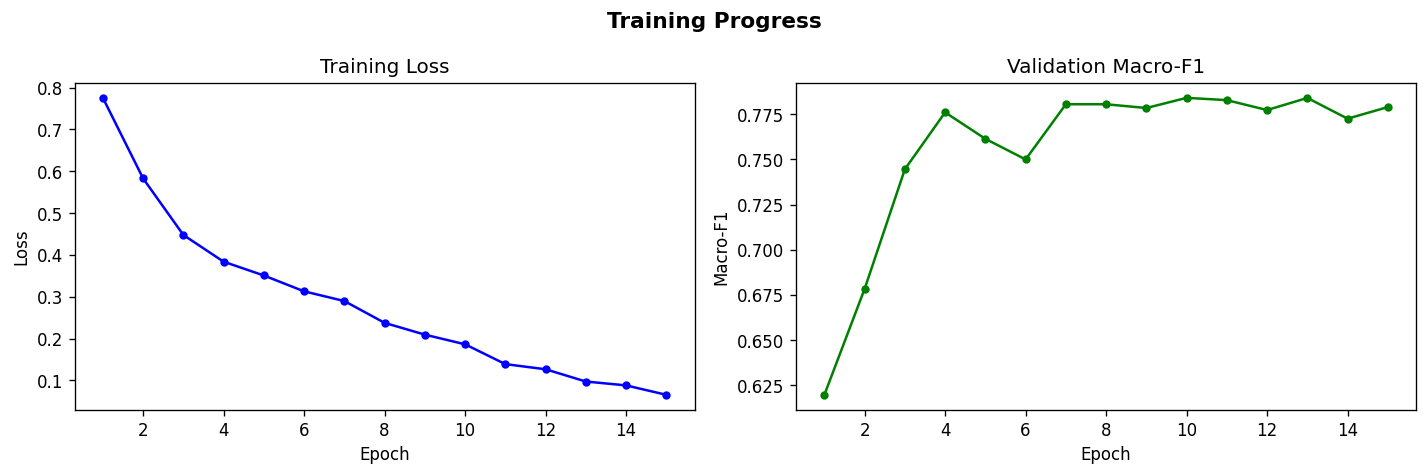

In [20]:
if RUN_PIPELINE:
    # Plot training curves (only available if training ran in this session)
    if trainer.history:
        plot_training_history(trainer.history)
    else:
        print('No training history (model was loaded from an existing checkpoint).')
    


---
## Section 9 - Evaluate on Test Set
---

In [21]:
if RUN_PIPELINE:
    import datetime
    
    print('Running evaluation on test set...')
    t_eval_start = time.time()
    raw_test = trainer.evaluate(test_loader)
    
    evaluator = AspectSentimentEvaluator(CONFIG['aspects']['names'])
    evaluator.evaluate_all(raw_test)
    
    # ── Build enriched results dict ──────────────────────────────────────────────
    def _ser(obj):
        """Make numpy types JSON-serialisable."""
        if isinstance(obj, np.ndarray): return obj.tolist()
        if isinstance(obj, (np.float32, np.float64)): return float(obj)
        if isinstance(obj, (np.int32, np.int64)): return int(obj)
        if isinstance(obj, dict):  return {k: _ser(v) for k, v in obj.items()}
        if isinstance(obj, list):  return [_ser(x) for x in obj]
        return obj
    
    # Determine best epoch from checkpoint if training was skipped (loaded from file)
    best_epoch = getattr(trainer, 'best_epoch', None)
    if best_epoch is None and CHECKPOINT_PATH.exists():
        try:
            ckpt_meta = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
            best_epoch = ckpt_meta.get('best_epoch', 'unknown')
        except Exception:
            best_epoch = 'unknown'
    
    output = {
        # ── Run metadata ─────────────────────────────────────────────────────
        'run_info': {
            'timestamp'          : datetime.datetime.now().isoformat(),
            'config_file'        : str(CONFIG_PATH),
            'checkpoint'         : str(CHECKPOINT_PATH),
            'best_epoch'         : best_epoch,
            'best_val_f1'        : round(getattr(trainer, 'best_val_f1', 0.0), 6),
            'training_duration_min': round(getattr(trainer, 'training_duration', 0.0), 2),
            'total_epochs_run'   : len(getattr(trainer, 'history', [])),
            'num_parameters'     : model.get_num_parameters(),
            'device'             : str(DEVICE),
            'roberta_model'      : CONFIG['model']['roberta_model'],
            'use_gcn'            : CONFIG['model']['use_dependency_gcn'],
            'use_aspect_attention': CONFIG['model']['use_aspect_attention'],
        },
        # ── Per-aspect test metrics ───────────────────────────────────────────
        'per_aspect': _ser({
            asp: {
                'accuracy'   : evaluator.results[asp]['accuracy'],
                'macro_f1'   : evaluator.results[asp]['macro_f1'],
                'weighted_f1': evaluator.results[asp]['weighted_f1'],
                'mcc'        : evaluator.results[asp]['mcc'],
                'roc_auc'    : evaluator.results[asp]['roc_auc'],
                'per_class_f1'       : evaluator.results[asp]['per_class_f1'],
                'per_class_precision': evaluator.results[asp]['per_class_precision'],
                'per_class_recall'   : evaluator.results[asp]['per_class_recall'],
                'support'            : evaluator.results[asp]['support'],
                'confusion_matrix'   : evaluator.results[asp]['confusion_matrix'],
            }
            for asp in CONFIG['aspects']['names'] if asp in evaluator.results
        }),
        # ── Overall test metrics ──────────────────────────────────────────────
        'overall': _ser({
            k: v for k, v in evaluator.results.get('overall', {}).items()
            if k not in ('y_true', 'y_prob', 'confusion_matrix')
        }),
        # ── Training history ──────────────────────────────────────────────────
        'training_history': getattr(trainer, 'history', []),
    }
    
    results_path = RESULTS_DIR / 'test_results.json'
    with open(results_path, 'w') as f:
        json.dump(output, f, indent=2)
    
    print(f"\n{'='*60}")
    print(f" Results saved to: {results_path}")
    print(f"{'='*60}")
    print(f"  Best epoch          : {best_epoch}")
    print(f"  Best val Macro-F1   : {getattr(trainer, 'best_val_f1', 0):.4f}")
    print(f"  Training duration   : {getattr(trainer, 'training_duration', 0):.1f} min")
    print(f"  Total epochs run    : {len(getattr(trainer, 'history', []))}")
    print(f"  Model parameters    : {model.get_num_parameters():,}")
    print(f"  Overall Macro-F1    : {evaluator.results.get('overall', {}).get('macro_f1', 0):.4f}")
    print(f"  Overall Accuracy    : {evaluator.results.get('overall', {}).get('accuracy', 0):.4f}")
    print(f"{'='*60}")
    


Running evaluation on test set...


[Evaluator] Tracking 7 aspects: ['stayingpower', 'texture', 'smell', 'price', 'colour', 'shipping', 'packing']
  [stayingpower]  acc=0.8567  macro_f1=0.8111  mcc=0.7454  roc_auc=0.9292
    per-class F1 → neg=0.8560  neu=0.6436  pos=0.8969
  [texture]  acc=0.9084  macro_f1=0.8104  mcc=0.7754  roc_auc=0.9564
    per-class F1 → neg=0.8658  neu=0.6119  pos=0.9535
  [smell]  acc=0.9327  macro_f1=0.7560  mcc=0.7869  roc_auc=0.9560
    per-class F1 → neg=0.8547  neu=0.4390  pos=0.9744
  [price]  acc=0.9653  macro_f1=0.4062  mcc=0.2429  roc_auc=0.8606
    per-class F1 → neg=0.0000  neu=0.2352  pos=0.9833
  [colour]  acc=0.9115  macro_f1=0.7234  mcc=0.6669  roc_auc=0.9331
    per-class F1 → neg=0.7817  neu=0.4285  pos=0.9599
  [shipping]  acc=0.9264  macro_f1=0.8011 mcc=0.8551  roc_auc=0.9646
    per-class F1 → neg=0.9404  neu=0.5000  pos=0.9628
  [packing]  acc=0.9801  macro_f1=0.7426  mcc=0.8030  roc_auc=0.9837
    per-class F1 → neg=0.8372  neu=0.400  pos=0.9906
  [overall]  acc=0.9236  macr

---
## Section 10 - Error Analysis and Mixed Sentiment Resolution (MSR) 
---

In [26]:
if RUN_PIPELINE:
    error_analyzer = ErrorAnalyzer(CONFIG['aspects']['names'])
    errors = error_analyzer.analyze_errors(
        texts = raw_test['texts'],         
        y_true  = raw_test['labels'],
        y_pred  = raw_test['preds'],
        aspects = raw_test['aspects'],
        save_path = str(RESULTS_DIR / 'errors.csv')
    )
    print(f'\nTotal misclassified samples: {len(errors)}')
    



[ErrorAnalyzer] Analysing 4465 predictions...
Total errors: 344 / 4465 (7.70%)

Error rate by aspect:
  colour          :  101 / 1130 (8.9%)
  packing         :    8 / 453 (1.8%)
  price           :   19 / 491 (3.9%)
  shipping        :   57 / 816 (7.0%)
  smell           :   32 / 431 (7.4%)
  stayingpower    :   51 / 412 (12.4%)
  texture         :   76 / 732 (10.4%)

Error type distribution:
  neutral→positive         :   93  (27.0%)
  negative→positive        :   77  (22.4%)
  positive→neutral         :   61  (17.7%)
  neutral→negative         :   57  (16.6%)
  negative→neutral         :   29  (8.4%)
  positive→negative        :   27  (7.8%)
Errors saved to c:\Users\lucif\Desktop\Clearview\ml-research\outputs\cosmetic_sentiment_v1\errors.csv

Total misclassified samples: 344


In [27]:
if RUN_PIPELINE:
    # Build per-review dicts for MSR evaluation
    review_true: dict = {}
    review_pred: dict = {}
    
    all_labels  = raw_test['labels']
    all_preds   = raw_test['preds']
    all_aspects = raw_test['aspects']
    
    # Re-run inference to recover review_ids (they are in the DataLoader batches)
    trainer.model.eval()
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='MSR pass'):
            preds = trainer._forward(batch)
            if isinstance(preds, tuple): preds = preds[0]
            pred_cls = torch.argmax(preds, dim=1).cpu().numpy()
            for i in range(len(pred_cls)):
                rid = batch['review_ids'][i]
                asp = batch['aspects'][i]
                lbl = batch['labels'][i].item()
                review_true.setdefault(rid, {})[asp] = lbl
                review_pred.setdefault(rid, {})[asp] = int(pred_cls[i])
    
    msr_evaluator = MixedSentimentEvaluator(CONFIG['aspects']['names'])
    msr_metrics   = msr_evaluator.evaluate_mixed_sentiment_resolution(review_true, review_pred)
    
    print(f"\n{'='*60}")
    print('MIXED SENTIMENT RESOLUTION RESULTS')
    print(f"{'='*60}")
    print(f"  Mixed reviews found    : {msr_metrics['mixed_review_count']}")
    print(f"  Mixed prevalence       : {msr_metrics['mixed_prevalence']:.2f}%  (of multi-aspect reviews)")
    print(f"  Review-level accuracy  : {msr_metrics['mixed_review_accuracy']:.2f}%")
    print(f"  Aspect-level accuracy  : {msr_metrics['mixed_aspect_accuracy']:.2f}%")
    print(f"{'='*60}")
    


MSR pass: 100%|██████████| 280/280 [00:35<00:00,  7.87it/s]


[MSREvaluator] Tracking 7 aspects


  Scoring: 100%|██████████| 628/628 [00:00<00:00, 1215515.88it/s]

[MSR] Review-level accuracy: 66.56%  |  Aspect-level accuracy: 87.22%

MIXED SENTIMENT RESOLUTION RESULTS
  Mixed reviews found    : 628
  Mixed prevalence       : 43.40%  (of multi-aspect reviews)
  Review-level accuracy  : 66.56%
  Aspect-level accuracy  : 87.22%


---
## Section 11 - Load Existing Checkpoint & Re-Evaluate

Use this section to load a **saved model** (e.g., from an earlier experiment runner run) without retraining.

---

Loading checkpoint from: c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments\A1_Full_model_best.pt


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Model] Created with 132,637,464 trainable parameters
Initializing tokenizer...
Building data loaders...
[DepParser] Loading spaCy model: en_core_web_sm
[DepParser] Ready

[Loaders] Using: DependencyParsingDataset  |  batch=16

[Dataset] Loading train split from: c:\Users\lucif\Desktop\Clearview\ml-research\data\splits\train_augmented.csv
[Dataset] 10050 rows  |  text_column='data'  |  max_len=256


  Expanding rows: 100%|██████████| 10050/10050 [00:00<00:00, 24772.32it/s]


[Dataset] Expanded to 22440 samples
[Dataset] Aspect distribution:
  stayingpower    : 2047
  texture         : 3622
  smell           : 2277
  price           : 2714
  colour          : 5410
  shipping        : 3889
  packing         : 2481
[Dataset] Label distribution:
  negative  : 3853
  neutral   : 2028
  positive  : 16559
[DepDataset] Pre-parsing 10041 unique texts...


...

  Expanding rows: 100%|██████████| 1994/1994 [00:00<00:00, 25029.16it/s]


[Dataset] Expanded to 4465 samples
[Dataset] Aspect distribution:
  stayingpower    : 412
  texture         : 732
  smell           : 431
  price           : 491
  colour          : 1130
  shipping        : 816
  packing         : 453
[Dataset] Label distribution:
  negative  : 695
  neutral   : 277
  positive  : 3493
[DepDataset] Pre-parsing 1994 unique texts...


  Parsing dependency trees: 100%|██████████| 1994/1994 [00:17<00:00, 111.38it/s]
C:\Users\lucif\AppData\Local\Temp\ipykernel_11216\1013206813.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler()


[Loaders] test: 4465 samples → 280 batches


[Evaluator] Tracking 7 aspects: ['stayingpower', 'texture', 'smell', 'price', 'colour', 'shipping', 'packing']
  [stayingpower]  acc=0.8568  macro_f1=0.7989  mcc=0.7454  roc_auc=0.9293
    per-class F1 → neg=0.8561  neu=0.6437  pos=0.8970
  [texture]  acc=0.9085  macro_f1=0.8104  mcc=0.7754  roc_auc=0.9565
    per-class F1 → neg=0.8658  neu=0.6119  pos=0.9536
  [smell]  acc=0.9327  macro_f1=0.7561  mcc=0.7869  roc_auc=0.9561
    per-class F1 → neg=0.8547  neu=0.4390  pos=0.9744
  [price]  acc=0.9654  macro_f1=0.4062  mcc=0.2429  roc_auc=0.8606
    per-class F1 → neg=0.0000  neu=0.2353  pos=0.9833
  [colour]  acc=0.9115  macro_f1=0.7234  mcc=0.6669  roc_auc=0.9331
    per-class F1 → neg=0.7817  neu=0.4286  pos=0.9600
  [shipping]  acc=0.9265  macro_f1=0.8011  mcc=0.8551  roc_auc=0.9647
    per-class F1 → neg=0.9405  neu=0.5000  pos=0.9629
  [packing]  acc=0.9801  macro_f1=0.7426  mcc=0.8031  roc_auc=0.9837
    per-class F1 → neg=0.8372  neu=0.4000  pos=0.9907
  [overall]  acc=0.9236  ma

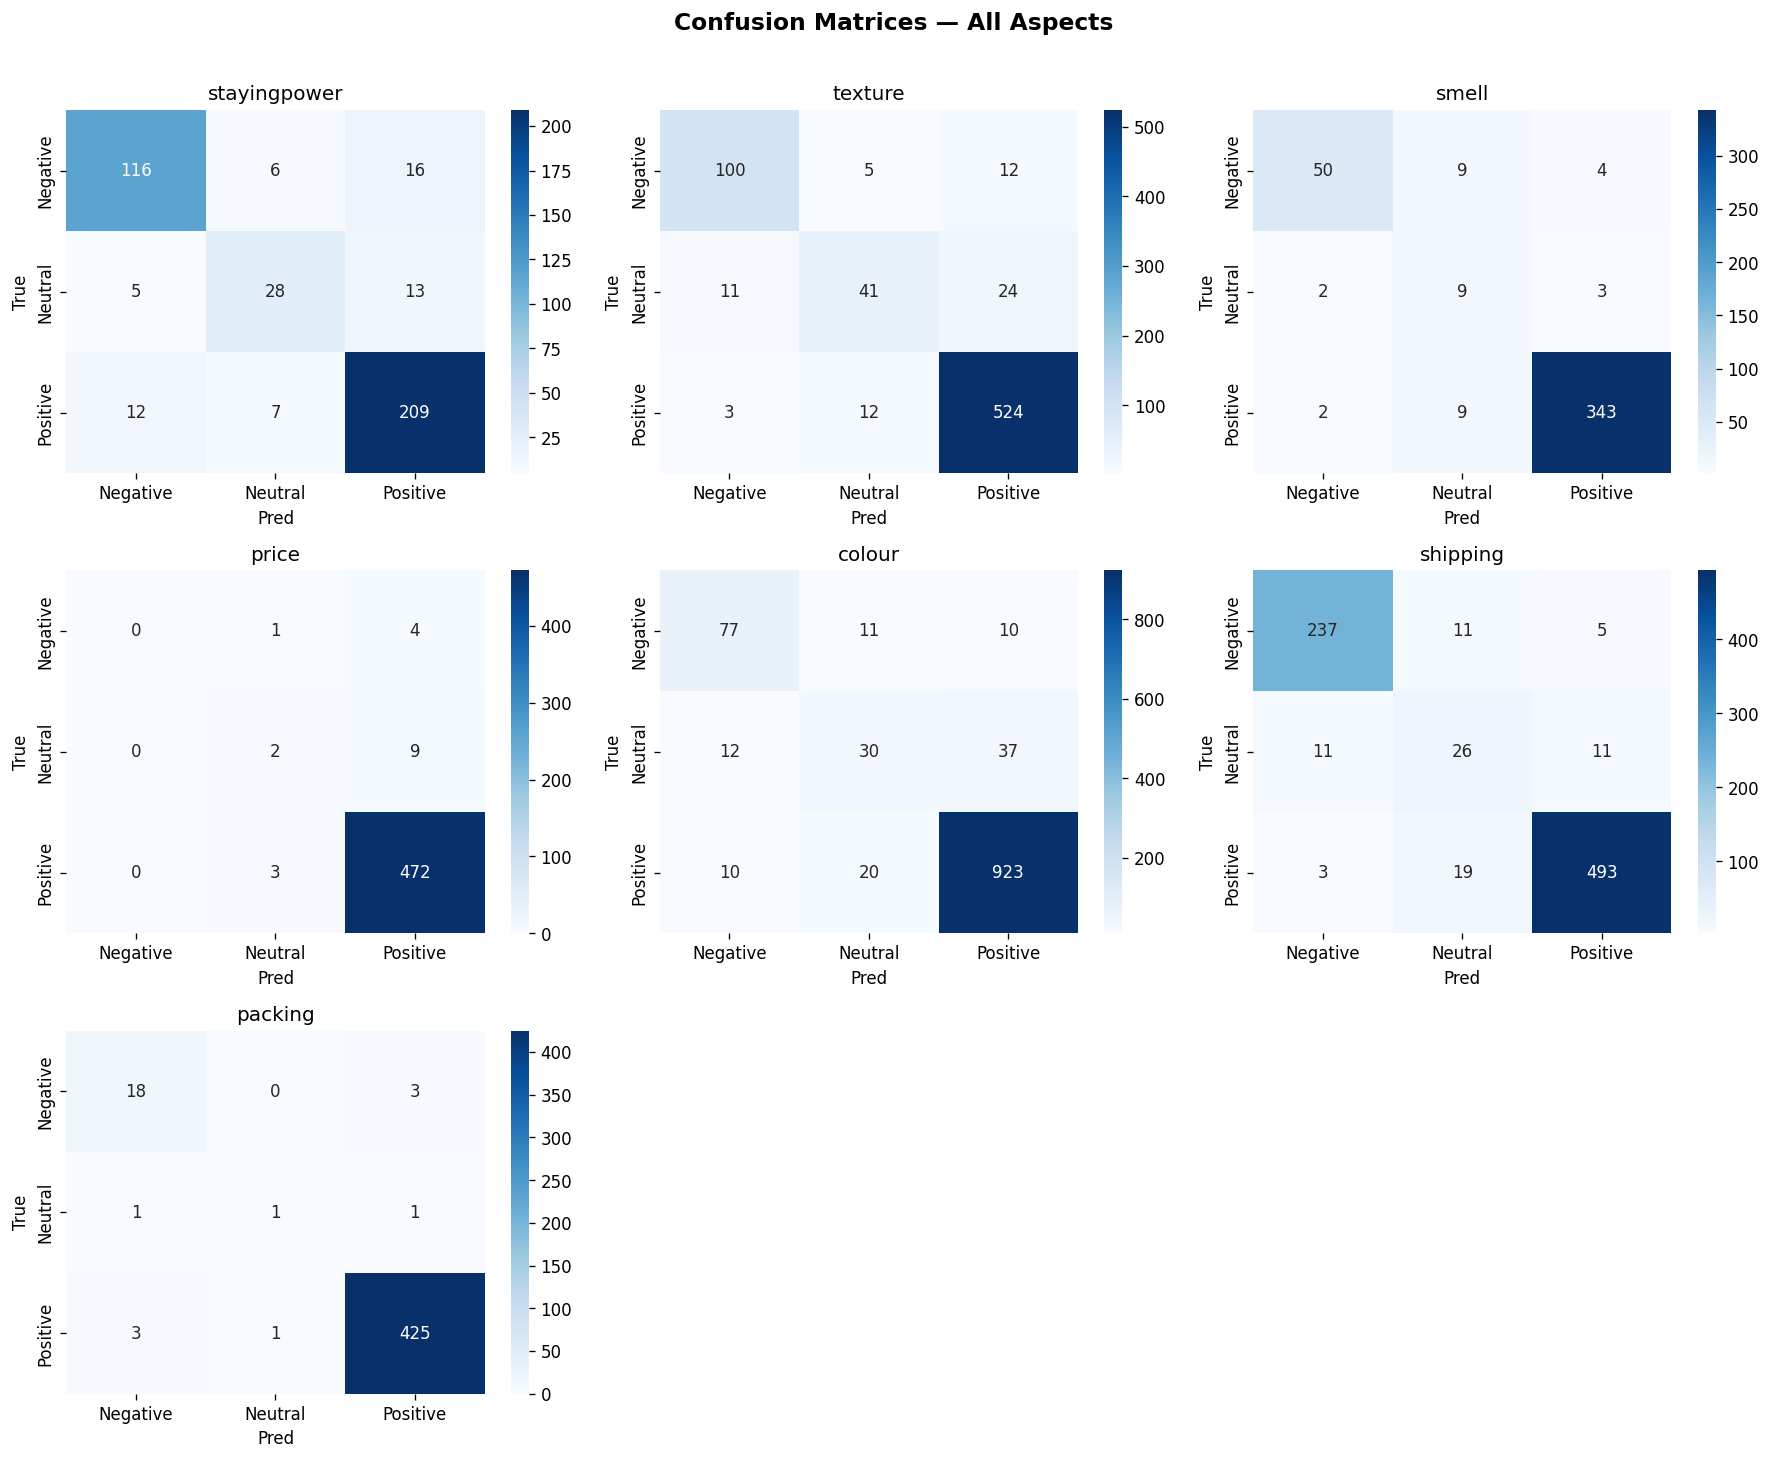

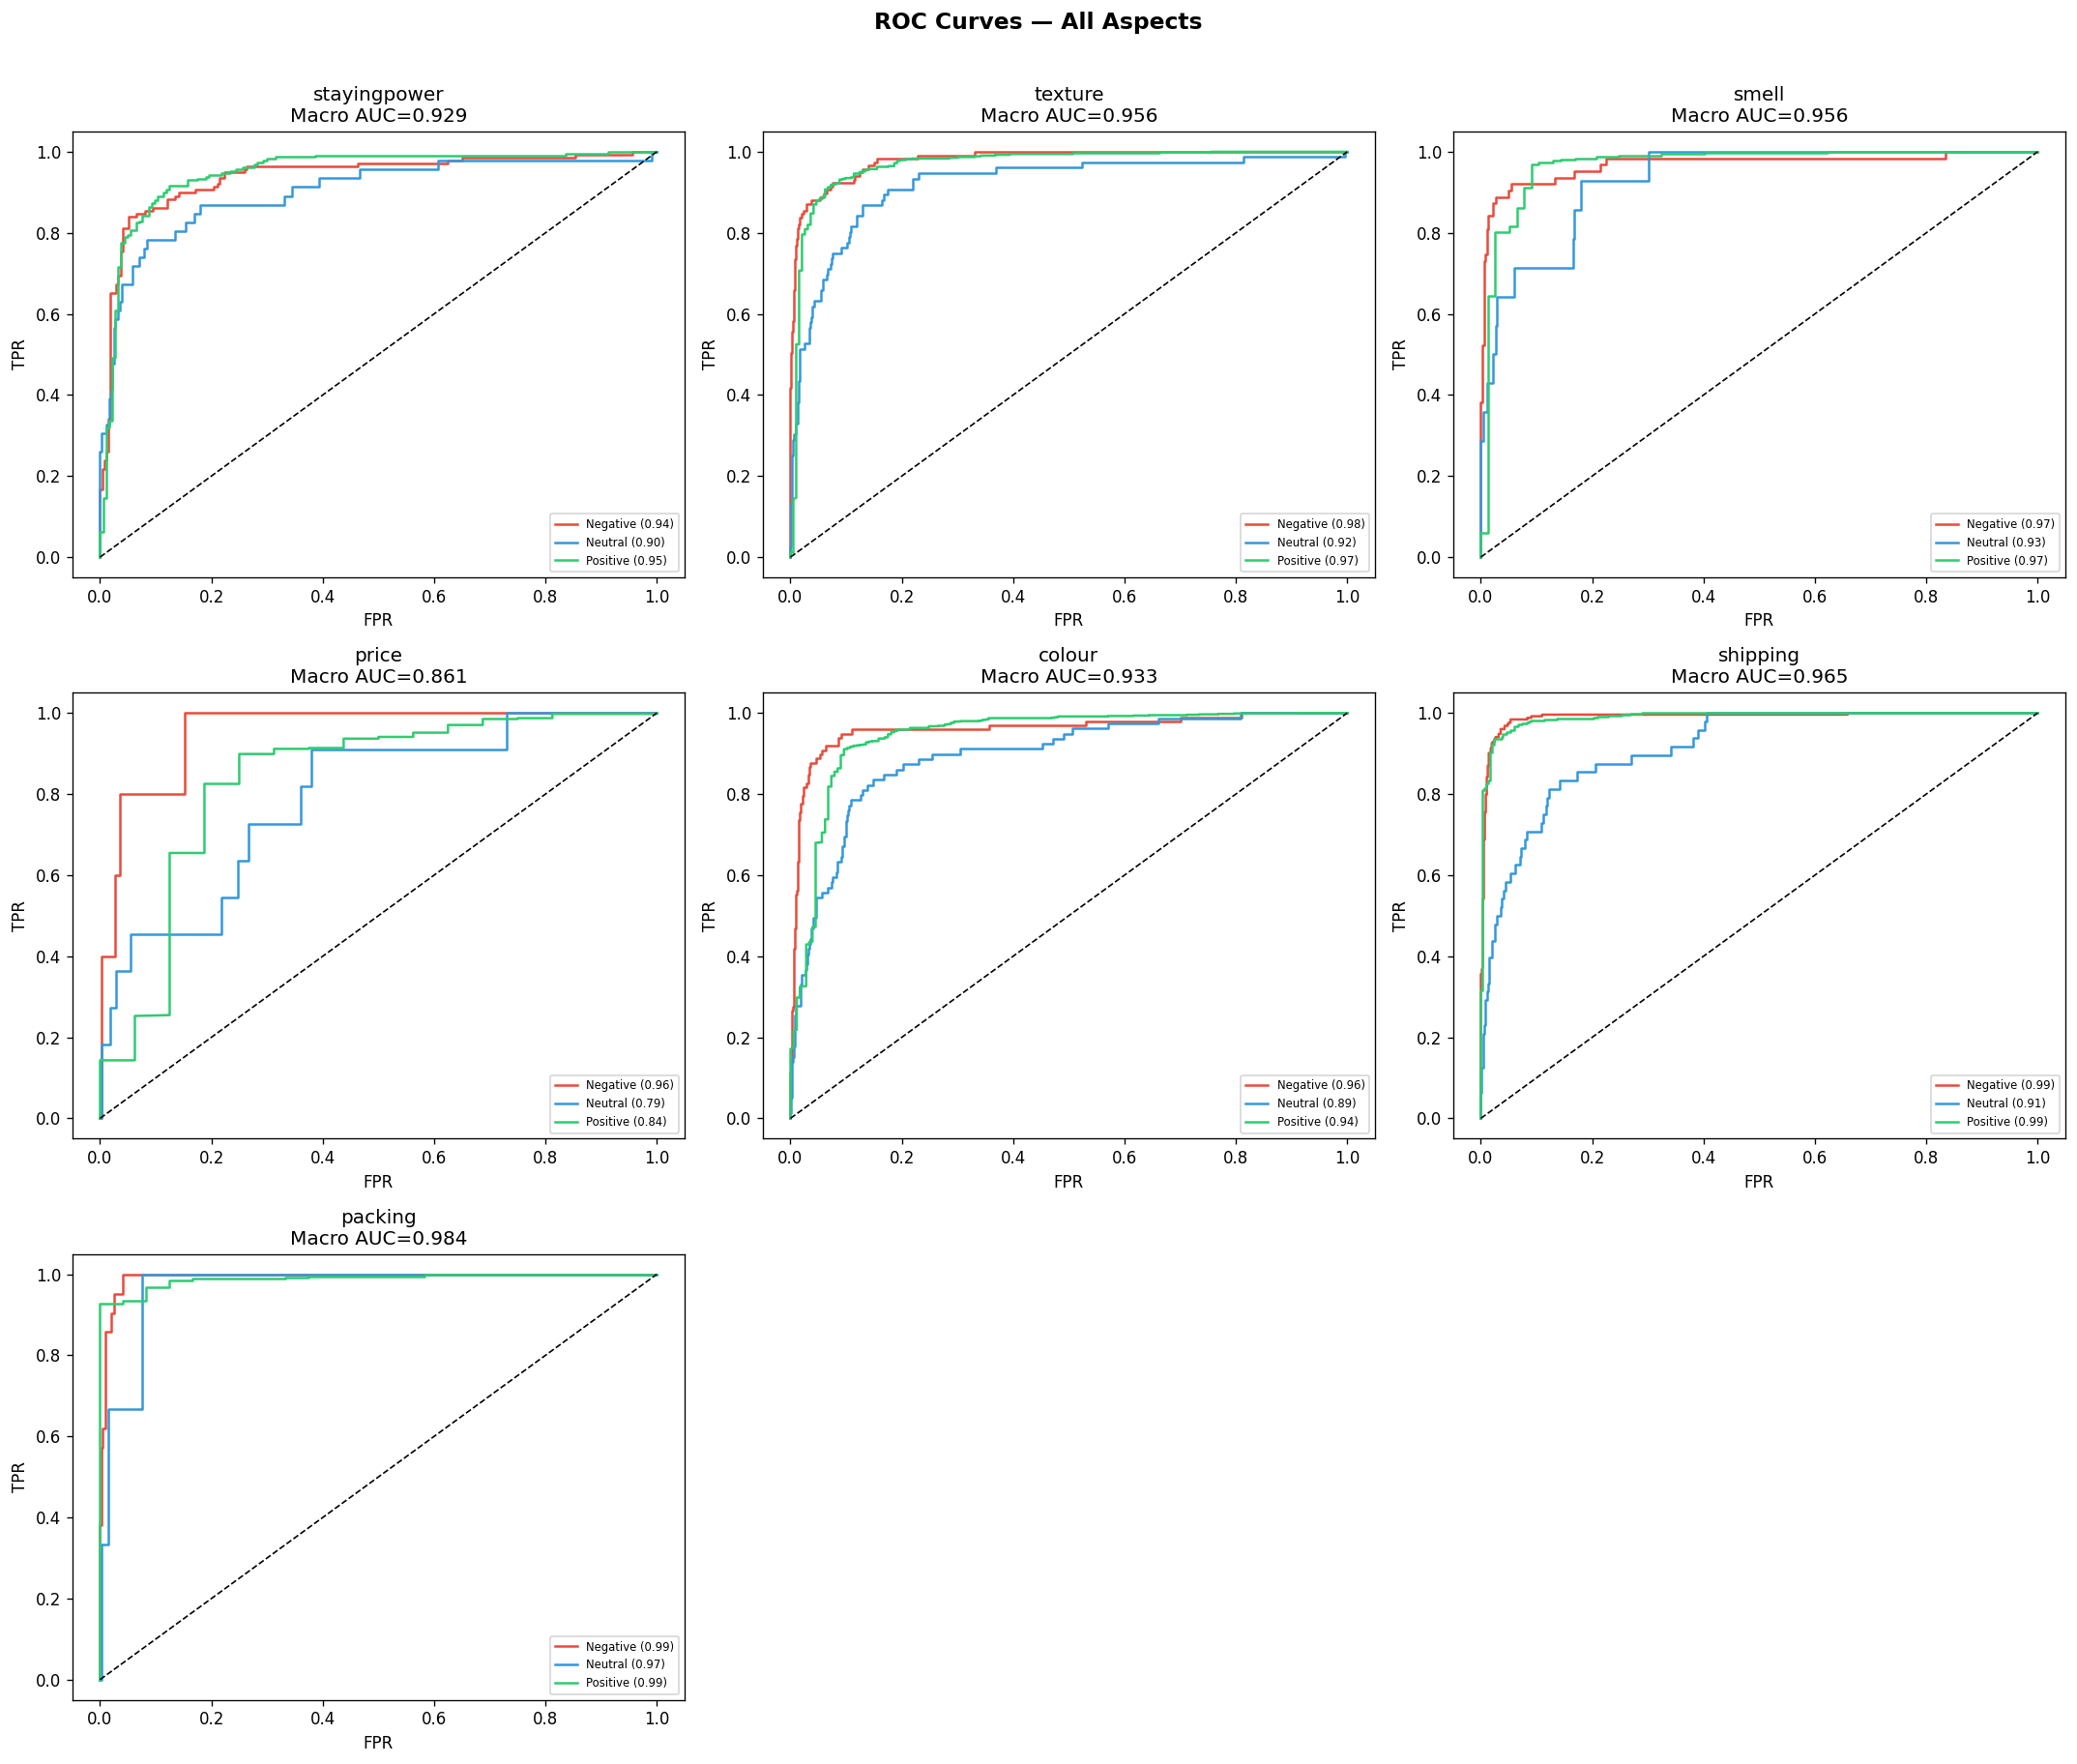

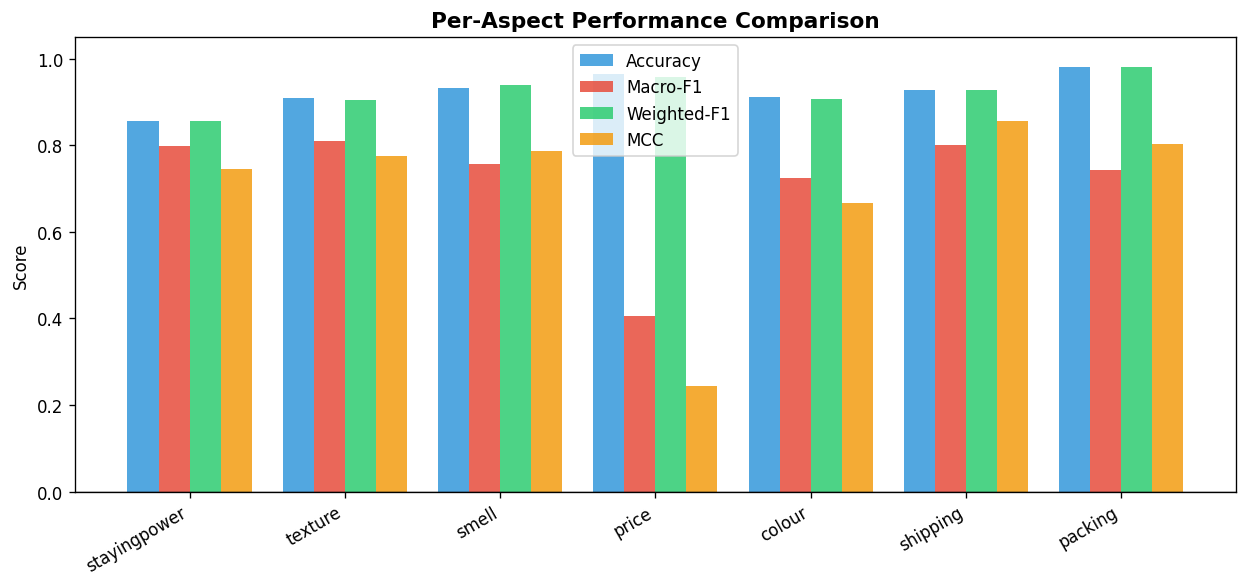

In [ ]:
if RUN_PIPELINE:
    # ── Change this path to point to any saved .pt checkpoint ────────────────────
    EXISTING_CHECKPOINT = ML_ROOT / 'outputs' / 'experiments' / 'A1_Full_model_best.pt'
    
    if EXISTING_CHECKPOINT.exists():
        print(f'Loading checkpoint from: {EXISTING_CHECKPOINT}')
        ckpt = torch.load(EXISTING_CHECKPOINT, map_location=DEVICE, weights_only=False)
    
        loaded_config = ckpt.get('config', CONFIG)   # Use saved config if available
        
        # Ensure data paths in loaded_config are absolute
        for key in ('train_path', 'val_path', 'test_path'):
            if key in loaded_config['data'] and not Path(loaded_config['data'][key]).is_absolute():
                loaded_config['data'][key] = str(ML_ROOT / loaded_config['data'][key])

        eval_model = create_model(loaded_config)
        eval_model.load_state_dict(ckpt['model_state_dict'])
        eval_model = eval_model.to(DEVICE).eval()
    
        # ── Ensure dependencies are initialized ──────────────────────────────────
        
        # 1. Tokenizer
        if 'tokenizer' not in locals():
            print("Initializing tokenizer...")
            from transformers import RobertaTokenizer
            tokenizer = RobertaTokenizer.from_pretrained(loaded_config['model']['roberta_model'])

        # 2. Data Loaders
        if 'test_loader' not in locals():
            print("Building data loaders...")
            # Initialize dep_parser if needed for loaders
            _tmp_dep_parser = None
            if loaded_config['data'].get('use_dependency_parsing', False):
                _tmp_dep_parser = DependencyParser('en_core_web_sm')
            
            # Note: assign to global-like variables used in Trainer
            train_loader, val_loader, test_loader = create_dataloaders(
                loaded_config, tokenizer, _tmp_dep_parser
            )

        # 3. Class weights and Loss Manager
        if 'aspect_class_counts' not in locals():
            print("Re-computing class weights from data...")
            aspect_class_counts = compute_class_weights(
                loaded_config['data']['train_path'],
                loaded_config['aspects']['names'],
                loaded_config['aspects']['label_map']
            )

        if 'loss_manager' not in locals() or loss_manager is None:
            print("Initializing loss manager for evaluation...")
            loss_manager = AspectSpecificLossManager(aspect_class_counts, loaded_config['training'])
    
        # ── Quick eval ───────────────────────────────────────────────────────────
        eval_trainer = Trainer(
            config=loaded_config, model=eval_model, loss_manager=loss_manager,
            tokenizer=tokenizer, train_loader=train_loader,
            val_loader=val_loader, test_loader=test_loader, device=DEVICE
        )
        raw_existing = eval_trainer.evaluate(test_loader)
    
        existing_evaluator = AspectSentimentEvaluator(loaded_config['aspects']['names'])
        existing_evaluator.evaluate_all(raw_existing)
    
        plot_all_confusion_matrices(existing_evaluator.results)
        plot_all_roc_curves(existing_evaluator.results)
        compare_aspects(existing_evaluator.results)
    else:
        print(f'Checkpoint not found: {EXISTING_CHECKPOINT}')
        print('Update EXISTING_CHECKPOINT to point to a valid .pt file.')
